<div align="center">

# Notebook 8 AST FINE TUNED + Vocoder

# Classification multi-class FOCH

**Branche Dual pour la classification**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)

</div>


## Synthèse de l'architecture configurable (upgrade notebook 5)

Cet upgrade rend l'architecture **entièrement pilotable par configuration**, pour comparer plusieurs backbones audio-domaine *sans réécrire la boucle d'entraînement*. 

**1 — Backbone configurable (`BACKBONE`, Cellule 1).** Un preset unique sélectionne la/les branche(s) ; la tête de fusion s'adapte automatiquement à la dimension d'embedding, et `forward(input_values, spec)` reste inchangé.

| Preset | Branche audio-domaine (AudioSet) | Branche WavLM | Fusion |
|---|---|---|---|
| `cnn14` *(défaut)* | CNN14 entraînable (2048-d) | WavLM-Base gelé (768-d) | 2816-d |
| `ast` | AST gelé (768-d) | WavLM-Base gelé (768-d) | 1536-d |
| `cnn14_solo` / `ast_solo` | CNN14 / AST seul | — | 2048 / 768-d |
| `wavlm_base` / `wavlm_large` | — | WavLM Base / Large gelé | 768 / 1024-d |

**2 — Gel de WavLM.** Gelé par défaut (`FREEZE_WAVLM=True`, config du meilleur résultat). **Dégel tardif et partiel** optionnel (`UNFREEZE_ENABLED`) : uniquement les `UNFREEZE_LAST_N` dernières couches, à partir de l'époque `UNFREEZE_AT_EPOCH` (≥ 20), à LR discriminant réduit — un petit jeu (~265 enregistrements) ne peut pas remodeler 95–300M paramètres sans dégrader la baseline gelée.

**3 — AST + budget mémoire.** AST chargé **en local** (`ast-finetuned-audioset-10-10-0.4593`), gelé, avec un fbank interne fixe (1024×128) indépendant de la fenêtre. L'arbitrage **fenêtre ↔ batch** est absorbé par l'accumulation de gradient (batch effectif ≈ 16) ; la **sonde VRAM (Cellule 6b)** dimensionne `BATCH_SIZE` — mesuré ≈ 0.27 Go/éch. (`cnn14`+WavLM-Base) → 8 Go : `BATCH_SIZE` 8 ; RTX 5070 Ti 16 Go : 16-24.

> Les explications détaillées accompagnent chaque section (Cellules 1, 6, 6b, 7).

## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection du backbone**. Le notebook met en œuvre un **classifieur multi-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Support intermédiaire |
| `fuite glottique` | FOCH | Support intermédiaire |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable du backbone (`BACKBONE`)

Le problème est plus proche de l'**analyse bioacoustique / de signal pathologique** que de la reconnaissance de parole ; on privilégie donc des backbones **audio-domaine pré-entraînés sur AudioSet** plutôt que des modèles centrés parole. Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding.

| Preset | Branche audio-domaine | Branche WavLM | Fusion |
|---|---|---|---|
| `cnn14` *(défaut)* | **CNN14** (PANNs/AudioSet, entraînable, 2048-d) | WavLM-Base gelé (768-d) | 2816-d |
| `ast` | **AST** (AudioSet, ViT spectral, gelé, 768-d) | WavLM-Base gelé (768-d) | 1536-d |
| `cnn14_solo` | CNN14 seul | — | 2048-d |
| `ast_solo` | AST seul | — | 768-d |
| `wavlm_base` | — | WavLM-Base gelé | 768-d |
| `wavlm_large` | — | WavLM-Large gelé (ancienne config nb 6) | 1024-d |
| `codec_solo` | **EnCodec** 24 kHz gelé (latent continu, 128-d) | — | 128-d |
| `wavlm_codec` | **EnCodec** 24 kHz gelé (128-d) | WavLM-Base gelé (768-d) | 896-d |
| `ast_codec` | **AST** gelé (768-d) + **EnCodec** gelé (128-d) | — | 896-d |

> 💡 **Choix WavLM-Base plutôt que Large** — la branche WavLM apporte le détail acoustique microscopique (jitter, shimmer, apériodicité). On retient la variante **Base** (95M) : dégeler/affiner 300M+ paramètres (Large) n'est pas justifié par la taille du jeu ni le budget de calcul. WavLM restant **gelé** par défaut, Base suffit ; Large reste sélectionnable (`wavlm_large`) au prix d'une VRAM plus élevée.

### Stratégie de gel de WavLM (résumé)

Par défaut `FREEZE_WAVLM=True` (embeddings gelés) — c'est la configuration du meilleur résultat obtenu jusqu'ici (**75.2 %**, WavLM gelé + planificateur LR, sans dégel). Un **dégel tardif partiel** optionnel (`UNFREEZE_ENABLED`) n'affine que les `UNFREEZE_LAST_N` dernières couches transformer, et seulement à partir de l'époque `UNFREEZE_AT_EPOCH`. Détails et justification en Cellule 6.

### Arbitrage fenêtre ↔ taille de batch

La **fenêtre audio** (`MAX_LEN_S`) fixe la résolution temporelle du spectrogramme Mel de CNN14 (`T = MAX_LEN/HOP + 1`). Une fenêtre plus **longue** = plus de trames = **plus de VRAM par échantillon**, ce qui force un **batch physique plus petit** (source d'instabilité de gradient constatée au notebook 6 avec un batch de 2). Deux leviers :

- **Accumulation de gradient** (`ACCUM_STEPS`) — conserve un **batch effectif** ≈ 16 même quand la VRAM impose un `BATCH_SIZE` de 2-4.
- **Chemin AST** — AST calcule un banc de filtres **interne de taille fixe** (1024×128) indépendant de `MAX_LEN_S` ; comme il est de plus **gelé** (pas d'activations à rétropropager dans ses 12 couches), il relâche fortement la contrainte VRAM par rapport à un WavLM-Large fine-tuné.

Repères VRAM **mesurés** (sonde 6b, `cnn14`+WavLM-Base, fenêtre 4 s ≈ **0.27 Go/échantillon**) : **8 Go** → `BATCH_SIZE` **8** confortable (bien au-delà du batch=2 du notebook 6 ; retomber à 4 si WavLM-Large gelé) ; **RTX 5070 Ti 16 Go** → 16-24 avec `ACCUM_STEPS`=1. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os
import gc
import glob
import random
import warnings

# ═══════════════════════════════════════════════════════════════════════════
# BUDGET CPU — À CONFIGURER AVANT TOUT IMPORT DE TORCH / NUMPY
# ═══════════════════════════════════════════════════════════════════════════
# Symptôme corrigé : pendant l'entraînement, la machine ENTIÈRE devenait
# inutilisable (navigation web saccadée), alors même que le GPU n'est chargé
# qu'à ~0.7 Go et que seuls ~116k paramètres sont entraînables.
#
# Cause : PyTorch dimensionne son pool OpenMP sur TOUS les cœurs (ici 16), et
# le runtime Intel OpenMP fait de l'attente ACTIVE (`KMP_BLOCKTIME` = 200 ms
# par défaut) après chaque région parallèle. Comme un pas GPU dure ~210 ms,
# les 16 threads ne se rendorment JAMAIS : ils tournent à vide pendant que le
# GPU travaille. Ce CPU est un Ultra 9 285H — 16 cœurs *sans* SMT — donc il ne
# reste aucun thread matériel pour l'OS, le compositeur de fenêtres ou le
# navigateur ; sur un châssis portable, CPU et GPU partagent en plus la même
# enveloppe thermique, et la contention fait throttler les deux.
#
# Mesuré sur cette machine (boucle d'entraînement réelle, preset ast_codec) :
#   16 threads + attente active : 409 ms/batch | CPU système  59 %
#    8 threads + attente passive: 355 ms/batch | CPU système  21 %
#    6 threads + attente passive: 359 ms/batch | CPU système  13 %
# Plafonner est donc GRATUIT : c'est à la fois plus fluide ET ~13 % plus rapide
# (les threads qui tournaient à vide volaient des cycles au thread principal,
# le seul qui alimente réellement le GPU).
#
# ⚠ Ces variables doivent être posées AVANT l'import de torch : le runtime
#   OpenMP les lit à son initialisation. Après un changement, REDÉMARRER LE
#   NOYAU (« Restart Kernel ») — ré-exécuter la cellule ne suffit pas.
CPU_RESERVED_CORES = 8    # cœurs LAISSÉS LIBRES pour l'OS / le navigateur
CPU_THREADS = max(1, (os.cpu_count() or 4) - CPU_RESERVED_CORES)

os.environ.setdefault('OMP_NUM_THREADS',  str(CPU_THREADS))
os.environ.setdefault('MKL_NUM_THREADS',  str(CPU_THREADS))
os.environ.setdefault('KMP_BLOCKTIME',    '0')         # pas d'attente active
os.environ.setdefault('OMP_WAIT_POLICY',  'PASSIVE')   # threads endormis hors calcul

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# Plafond appliqué aussi via l'API torch : couvre le cas où le noyau avait déjà
# importé torch (les variables d'environnement ci-dessus sont alors ignorées).
torch.set_num_threads(CPU_THREADS)
try:
    # Ne peut être appelé qu'une seule fois, avant tout travail inter-op.
    torch.set_num_interop_threads(max(1, CPU_THREADS // 2))
except RuntimeError:
    pass   # déjà initialisé (cellule ré-exécutée sans redémarrage du noyau)

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'orl_df_vowel_master_updated_20260803.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées — SpecAugment UNIQUEMENT ──────────────────────────────
# Un seul pool d'augmentation est actif, afin d'ISOLER l'effet de SpecAugment.
# Les deux autres pools présents sur le disque sont volontairement ÉCARTÉS :
#   • manifest_train_bal.csv     → augmentations « signal »        (123 seg.) ✗
#   • manifest_train_bal_vc.csv  → conversion de voix Seed-VC      (354 seg.) ✗
#   • augmentation_manifest_specaug.csv → SpecAugment              (330 seg.) ✓
#
# Le manifeste SpecAugment est produit par `specaug/specaug.ipynb` : masquage
# temps/fréquence appliqué sur la STFT LINÉAIRE (et non le mel), puis resynthèse
# ISTFT à PHASE PRÉSERVÉE → de vrais .wav, exploitables par les deux branches.
# Il vit dans le dépôt (et non dans AUG_DIR), mais pointe vers des .wav écrits
# dans AUG_DIR/specaugment/.
#
# Répartition du pool (330 segments) et effectifs d'entraînement résultants :
#   fuite glottique 120 → 26 + 120 = 146     LMB      90 →  66 +  90 = 156
#   PR               60 → 72 +  60 = 132     Healthy  60 → 100 +  60 = 160
# soit un pool CALIBRÉ pour rééquilibrer les classes (la minoritaire 'fuite
# glottique', 26 originaux, reçoit le plus gros contingent).
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SPECAUG_DIR = os.path.join(AUG_DIR, 'specaugment')   # .wav SpecAugment resynthétisés
AUG_MANIFESTS   = [
    r'C:/Users/AdminIA/Desktop/Foch_Classif_Final/data/augmentation_manifest_specaug.csv',
]

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DU BACKBONE  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Le classifieur est un réseau MULTI-BRANCHE. On sépare deux rôles :
#   • une branche « audio-domaine » (spectrale), au choix CNN14 ou AST, toutes
#     deux pré-entraînées sur AudioSet → adaptées à l'analyse bioacoustique /
#     pathologique du signal plutôt qu'à la reconnaissance de parole ;
#   • une branche WavLM OPTIONNELLE (détail acoustique fin : jitter/shimmer),
#     en variante Base (défaut) plutôt que Large — cf. stratégie de gel ci-dessous.
#
# On sélectionne un preset unique ; le reste du notebook (Dataset, modèle, boucle
# d'entraînement) s'adapte automatiquement aux dimensions d'embedding.
#
#   'cnn14'       → CNN14 (PANNs/AudioSet)        + WavLM-Base gelé   [DÉFAUT]
#   'ast'         → AST (AudioSet, ViT spectral)  + WavLM-Base gelé
#   'cnn14_solo'  → CNN14 seul   (pas de WavLM)
#   'ast_solo'    → AST seul     (pas de WavLM)
#   'wavlm_base'  → WavLM-Base seul (pas de branche spectrale)
#   'wavlm_large' → WavLM-Large seul (ancienne config notebook 6 ; gelé)
#   'codec_solo'  → EnCodec 24 kHz seul (gelé)
#   'wavlm_codec' → WavLM-Base gelé   + EnCodec gelé
#   'ast_codec'   → AST gelé          + EnCodec gelé
#
BACKBONE = 'ast_codec'

_BACKBONE_PRESETS = {
    'cnn14':       {'audio': 'cnn14', 'wavlm': 'base'},
    'ast':         {'audio': 'ast',   'wavlm': 'base'},
    'cnn14_solo':  {'audio': 'cnn14', 'wavlm': None},
    'ast_solo':    {'audio': 'ast',   'wavlm': None},
    'wavlm_base':  {'audio': None,    'wavlm': 'base'},
    'wavlm_large': {'audio': None,    'wavlm': 'large'},
    'ast_large':   {'audio': 'ast',   'wavlm': 'large'},
    'cnn14_large': {'audio': 'cnn14', 'wavlm': 'large'},
    # ── Presets « codec neuronal » (cf. note terminologique avant la Cellule 6) ──
    # La clé 'codec' est ABSENTE des presets ci-dessus : le .get('codec', False)
    # plus bas les laisse donc strictement inchangés.
    'codec_solo':  {'audio': None,    'wavlm': None,    'codec': True},
    'wavlm_codec': {'audio': None,    'wavlm': 'base',  'codec': True},
    'ast_codec':   {'audio': 'ast',   'wavlm': None,    'codec': True},
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
AUDIO_BACKBONE = _BACKBONE_PRESETS[BACKBONE]['audio']    # 'cnn14' | 'ast' | None
WAVLM_VARIANT  = _BACKBONE_PRESETS[BACKBONE]['wavlm']    # 'base'  | 'large' | None
USE_CODEC      = _BACKBONE_PRESETS[BACKBONE].get('codec', False)   # branche codec neuronal

# ── Chemins locaux des backbones ─────────────────────────────────────────────
WAVLM_DIRS = {
    'base':  r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'large': r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
AST_DIR     = r'C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593'  # chargé en LOCAL
WAVLM_DIR   = WAVLM_DIRS.get(WAVLM_VARIANT)             # None si pas de branche WavLM
MODEL_DIR   = WAVLM_DIR or WAVLM_DIRS['base']           # dir du processor WavLM (rétro-compat)
WAVLM_EMB_DIM = {'base': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]
AST_EMB_DIM   = 768

# ── Poids CNN14 pré-entraînés — stratégie de chargement ──────────────────────
CNN14_CKPT_PATH  = r'C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt'  # chemin LOCAL du checkpoint CNN14
CNN14_PRETRAINED = True   # mettre False pour ignorer tout chargement de poids
CNN14_EMB_DIM    = 2048

# ── AST : gel par défaut (86M params ViT → non affinables sur ~265 échantillons) ─
FREEZE_AST = True         # AST utilisé comme extracteur d'embeddings (pooler 768-d)

# ── Codec neuronal (EnCodec) — extracteur de features gelé ───────────────────
# Un VOCODEUR (HiFi-GAN, Vocos, BigVGAN) est un DÉCODEUR : mel → forme d'onde.
# Il n'a aucun encodeur appris dont on puisse extraire un embedding. Pour tenir
# la promesse « vocodeur comme extracteur de features », on utilise donc un
# CODEC NEURONAL (EnCodec), qui associe un vrai encodeur pré-entraîné à un
# décodeur de type vocodeur. C'est la sortie CONTINUE de l'encodeur (AVANT la
# quantification RVQ) qui sert de branche de features. Cf. note markdown §6.
CODEC_DIR     = r'C:/Users/AdminIA/Documents/models/encodec_24khz'  # chargé en LOCAL
CODEC_HF_ID   = 'facebook/encodec_24khz'   # repli réseau si le dossier local est absent
CODEC_SR      = 24000     # EnCodec 24 kHz → ré-échantillonnage DÉDIÉ (≠ 16 kHz WavLM/AST)
FREEZE_CODEC  = True      # extracteur d'embeddings uniquement (même logique que WavLM/AST)
# Goulet OPTIONNEL appliqué à l'embedding codec AVANT la concaténation (cf.
# Cellule 9, piste 6 : réduire fusion_dim si la tête surapprend). NB : le latent
# continu d'EnCodec 24 kHz ne fait déjà que 128-d — bien moins que WavLM (768 /
# 1024) ou AST (768) — donc il n'élargit PAS la tête de fusion et la projection
# est inutile ici ; elle reste à None par défaut. Elle redevient pertinente si
# l'on substitue un codec à latent plus large (p. ex. Descript Audio Codec, 1024-d).
CODEC_BOTTLENECK_DIM = None   # None = aucune projection | 128 / 256 = projection

def _codec_source(codec_dir=None, need_weights=True):
    """Source à passer à `from_pretrained` : dossier LOCAL s'il est exploitable,
    sinon repli sur l'identifiant HuggingFace.

    `need_weights=True` exige en plus la présence effective des poids : un
    dossier seulement à moitié téléchargé (config.json sans *.safetensors)
    ne doit pas faire échouer le chargement du modèle. L'extracteur de
    features, lui, n'a besoin que du preprocessor_config.json."""
    d = codec_dir or CODEC_DIR
    if os.path.isdir(d):
        if not need_weights:
            return d
        if glob.glob(os.path.join(d, '*.safetensors')) or glob.glob(os.path.join(d, '*.bin')):
            return d
        print(f'[CODEC] {d} présent mais sans poids → repli réseau ({CODEC_HF_ID}).')
    return CODEC_HF_ID

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
# La FENÊTRE (MAX_LEN_S) fixe la résolution temporelle du spectrogramme CNN14
# (T = MAX_LEN/HOP+1). Une fenêtre plus longue = plus de trames = plus de VRAM
# par échantillon → force un batch plus petit. Voir la note markdown ci-dessus
# sur l'arbitrage fenêtre ↔ batch. AST ignore cette config (fbank interne fixe
# 1024×128) et pardonne donc mieux les fenêtres longues.
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)
N_FFT        = 1024
HOP_LENGTH   = 256
N_MELS       = 128
MEL_FRAMES   = MAX_LEN // HOP_LENGTH + 1
# Fenêtre de la branche codec : même durée, mais à la fréquence propre du
# codec (24 kHz) — chaîne de ré-échantillonnage indépendante de WavLM/AST.
CODEC_MAX_LEN = int(CODEC_SR * MAX_LEN_S)

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
# Budget mémoire (MESURÉ par la sonde VRAM, Cellule 6b) :
#   • cnn14 + WavLM-Base gelé, fenêtre 4s : ~0.27 Go/échantillon (1 pas fwd+bwd).
#   • Portable 8 Go VRAM  : BATCH_SIZE=8 confortable (cnn14/ast + WavLM-Base) —
#     bien au-delà du batch=2 du notebook 6 (source d'instabilité). Retomber à 4
#     seulement si WavLM-Large gelé est sélectionné, ou en cas d'OOM.
#   • RTX 5070 Ti 16 Go   : BATCH_SIZE 16-24 → ACCUM_STEPS 1 (plus besoin d'accum).
# Le batch EFFECTIF (BATCH_SIZE × ACCUM_STEPS) reste la grandeur qui stabilise
# l'entraînement ; l'accumulation le maintient à ~16 même si la VRAM impose un
# petit BATCH_SIZE physique. Relancer la sonde 6b après un changement de
# BACKBONE / MAX_LEN_S / BATCH_SIZE.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2          # batch effectif = BATCH_SIZE × ACCUM_STEPS = 16
EPOCHS          = 30
LR              = 1e-4
WEIGHT_DECAY    = 0.1         # ↑ 0.05→0.1 : L2 plus fort sur la tête (seule partie entraînable ici)
PATIENCE        = 6
DROPOUT         = 0.5         # ↑ 0.25→0.5 : la tête est très overparamétrée (fusion 1792-d, ~300 échantillons)
HIDDEN_DIM      = 128         # ↓ 512→128 : réduit les paramètres entraînables d'un facteur ~4 (moins de capacité à mémoriser)
INPUT_DROPOUT   = 0.3         # NOUVEAU : dropout appliqué directement sur l'embedding fusionné (avant la 1re Linear)
FOCAL_GAMMA     = 2.0        # FocalLoss : concentre le gradient sur les exemples mal classés (classe minoritaire 'fuite glottique', 26 éch.)

# ── Dosage de l'augmentation & assiette des poids de classes ─────────────
# AUG_MAX_PER_PATIENT : nombre MAXIMAL de segments augmentés conservés par
# patient (Last_Name), toutes classes confondues. Sans plafond, le pool
# SpecAugment injectait 120 segments pour 'fuite glottique' issus de seulement
# 26 patients (~4.6 copies/patient, ~5.5 en comptant l'original) contre ~1.6
# pour Healthy : la classe minoritaire n'était pas plus DIVERSE, juste rejouée
# 5 fois par époque → le modèle mémorise le LOCUTEUR plutôt que la pathologie.
# None = aucun plafond (ancien comportement).
AUG_MAX_PER_PATIENT = 2

# CLASS_WEIGHTS_ON : assiette de calcul des poids inverse-fréquence (Cellule 7).
#   'original'   → comptes du pli AVANT injection des segments augmentés [DÉFAUT]
#   'train_full' → comptes APRÈS injection (ancien comportement)
# Le pool SpecAugment est CALIBRÉ pour rééquilibrer les classes : calculé sur
# train_full, l'inverse-fréquence retombait donc à ~1.0 partout (PR 1.118 /
# LMB 0.931 / fuite 1.012 / Healthy 0.939) et la pondération était un no-op
# silencieux. Sur les comptes ORIGINAUX elle retrouve son amplitude utile
# (fuite glottique ≈ 1.97 vs Healthy ≈ 0.52).
CLASS_WEIGHTS_ON = 'original'

# ── Stratégie de gel / dégel de WavLM (cf. Cellule 6 & note markdown) ────────
# Par défaut WavLM reste GELÉ (embeddings) — c'est la config du meilleur résultat
# (75.2 % avec WavLM gelé + planificateur LR, sans dégel). Le dégel tardif partiel
# est OPTIONNEL : ne dégeler que les dernières couches, et seulement à partir de
# l'époque UNFREEZE_AT_EPOCH (jamais dès le départ).
FREEZE_WAVLM       = True    # WavLM gelé par défaut
UNFREEZE_ENABLED   = False   # activer le dégel tardif partiel
UNFREEZE_AT_EPOCH  = 8      # époque de départ du dégel (>= 20 conseillé)
UNFREEZE_LAST_N    = 4       # nb de couches transformer finales à dégeler (3-4)
UNFREEZE_LR        = 1e-5    # LR discriminant réduit pour les couches dégelées

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if WAVLM_VARIANT:              _dims.append(('WavLM-' + WAVLM_VARIANT, WAVLM_EMB_DIM))
if AUDIO_BACKBONE == 'cnn14':  _dims.append(('CNN14', CNN14_EMB_DIM))
elif AUDIO_BACKBONE == 'ast':  _dims.append(('AST', AST_EMB_DIM))
# Dimension du codec : LUE à la volée dans la config du modèle chargé (Cellule 6),
# jamais devinée ici. Elle n'est donc connue d'avance que si l'on force une
# projection (CODEC_BOTTLENECK_DIM) — sa sortie est alors de notre choix. Sinon
# FUSION_DIM_EXPECTED vaut None et le contrôle exact de la Cellule 6 devient un
# simple report.
if USE_CODEC and not CODEC_BOTTLENECK_DIM:
    _dims.append(('EnCodec', None))
    FUSION_DIM_EXPECTED = None
else:
    if USE_CODEC:
        _dims.append(('EnCodec→proj', CODEC_BOTTLENECK_DIM))
    FUSION_DIM_EXPECTED = sum(d for _, d in _dims)

if not CNN14_PRETRAINED:
    _cnn14_status = 'initialisation ALÉATOIRE (CNN14_PRETRAINED=False)'
elif CNN14_CKPT_PATH and os.path.isfile(CNN14_CKPT_PATH):
    _cnn14_status = f'chemin LOCAL → {CNN14_CKPT_PATH}'
else:
    _cnn14_status = 'téléchargement réseau (miroir hf-mirror.com → HuggingFace Hub)'

print('Configuration chargée.')
print(f'  Preset backbone : {BACKBONE}  (audio={AUDIO_BACKBONE}, wavlm={WAVLM_VARIANT})')
print(f'  Classes ({NUM_LABELS}) : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch.) | Mel ({N_MELS}, {MEL_FRAMES})')
_dims_txt = ' + '.join(f'{n}({d if d is not None else "?"})' for n, d in _dims)
print(f'  Branches actives: {_dims_txt} → fusion '
      + (f'{FUSION_DIM_EXPECTED}-d' if FUSION_DIM_EXPECTED is not None
         else '?-d (dimension codec lue au chargement, Cellule 6)'))
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  WavLM           : {"gelé" if FREEZE_WAVLM else "entraînable"}'
      + (f' | dégel tardif ON (>= epoch {UNFREEZE_AT_EPOCH}, {UNFREEZE_LAST_N} couches)' if UNFREEZE_ENABLED else ' | dégel OFF'))
if AUDIO_BACKBONE == 'cnn14':
    print(f'  CNN14 poids     : {_cnn14_status}')
elif AUDIO_BACKBONE == 'ast':
    print(f'  AST             : {"gelé" if FREEZE_AST else "entraînable"} ← {AST_DIR}')
if USE_CODEC:
    _codec_src = _codec_source()
    print(f'  Codec           : EnCodec {CODEC_SR // 1000} kHz '
          f'{"gelé" if FREEZE_CODEC else "entraînable"} ← {_codec_src}')
    print(f'                    fenêtre {MAX_LEN_S}s → {CODEC_MAX_LEN} éch. @ {CODEC_SR} Hz '
          f'| projection : {CODEC_BOTTLENECK_DIM or "aucune"}')
print(f'  Device          : {device}')
print(f'  Threads CPU     : {torch.get_num_threads()} / {os.cpu_count()} cœurs '
      f'({CPU_RESERVED_CORES} réservés à l\'OS) | KMP_BLOCKTIME='
      f'{os.environ.get("KMP_BLOCKTIME", "?")}')
if device.type == 'cuda':
    _gp = torch.cuda.get_device_properties(0)
    _free_b, _total_b = torch.cuda.mem_get_info()
    print(f'  GPU             : {_gp.name}')
    print(f'                    {_total_b / 1024**3:.1f} Go au total, '
          f'{_free_b / 1024**3:.1f} Go libres '
          f'({(_total_b - _free_b) / 1024**3:.1f} Go déjà pris par le bureau/navigateur)')

FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset backbone : ast_codec  (audio=ast, wavlm=None)
  Classes (4) : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch.) | Mel (128, 251)
  Branches actives: AST(768) + EnCodec(?) → fusion ?-d (dimension codec lue au chargement, Cellule 6)
  Batch           : 8 × 2 (accum) = 16 effectif
  WavLM           : gelé | dégel OFF
  AST             : gelé ← C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
  Codec           : EnCodec 24 kHz gelé ← C:/Users/AdminIA/Documents/models/encodec_24khz
                    fenêtre 4.0s → 96000 éch. @ 24000 Hz | projection : aucune
  Device          : cuda
  Threads CPU     : 8 / 16 cœurs (8 réservés à l'OS) | KMP_BLOCKTIME=0
  GPU             : NVIDIA RTX PRO 2000 Blackwell Gener

## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  311 lignes
Lignes pathologiques retenues :  213  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (48 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  77
LMB                 62
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  77
1      LMB                 62
2      fuite glottique     26
3      Healthy            100


## 4. Processor WavLM et `Dataset` bi-branche

Le `Dataset` encapsule la chaîne de prétraitement et produit, pour chaque enregistrement, les **deux entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM)** — extraction de features via le `Wav2Vec2FeatureExtractor` (normalisation + padding) → `input_values` ;
3. **Branche B (Mel)** — `MelSpectrogram` → conversion en dB (`AmplitudeToDB`) → normalisation par échantillon → image temps-fréquence à 1 canal `(1, n_mels, T)`.

> 🛡️ **Robustesse** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` renvoie des tenseurs nuls de secours (forme d'onde + Mel) en signalant le fichier fautif.

> ℹ️ WavLM réutilise l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe « WavLMFeatureExtractor » dédiée.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processor WavLM + Dataset bi-branche (WavLM input + Mel)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# WavLM réutilise l'extracteur de features de Wav2Vec2 (normalisation + padding).
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_DIR)
print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(MODEL_DIR)}')

# Extracteur de features AST (uniquement si la branche AST est active). AST calcule
# son PROPRE banc de filtres (128 mel × 1024 trames, normalisation AudioSet) à
# partir de la forme d'onde brute — indépendant de la config Mel de la Cellule 1.
ast_extractor = None
if AUDIO_BACKBONE == 'ast':
    from transformers import ASTFeatureExtractor
    ast_extractor = ASTFeatureExtractor.from_pretrained(AST_DIR)
    print(f'✓ Extracteur AST chargé : {type(ast_extractor).__name__} (fbank {ast_extractor.num_mel_bins}×{ast_extractor.max_length})')

# Extracteur de features EnCodec (uniquement si la branche codec est active).
# EnCodec 24 kHz attend la forme d'onde BRUTE à 24 kHz en (canaux, échantillons)
# — et NON le tenseur WavLM, qui est à 16 kHz et normalisé par le processor. On
# lui fournit donc une entrée ré-échantillonnée INDÉPENDAMMENT (cf. Dataset
# ci-dessous), exactement comme AST reçoit son propre fbank indépendant de WavLM.
codec_extractor = None
if USE_CODEC:
    from transformers import EncodecFeatureExtractor
    _codec_src = _codec_source(need_weights=False)
    codec_extractor = EncodecFeatureExtractor.from_pretrained(_codec_src)
    assert codec_extractor.sampling_rate == CODEC_SR, (
        f'CODEC_SR={CODEC_SR} incohérent avec l\'extracteur ({codec_extractor.sampling_rate} Hz)')
    print(f'✓ Extracteur EnCodec chargé : {type(codec_extractor).__name__} '
          f'({codec_extractor.sampling_rate} Hz, {codec_extractor.feature_size} canal) ← {_codec_src}')


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit DEUX représentations pour
    le modèle de fusion bi-branche :

      • `input_values` — forme d'onde brute (16 kHz, normalisée) destinée à la
        Branche A (WavLM-Large), via le `Wav2Vec2FeatureExtractor` ;
      • `spec`         — représentation spectrale destinée à la branche audio :
        soit un log-Mel en dB normalisé `(1, N_MELS, T)` pour CNN14, soit le
        banc de filtres AST `(1, 1024, 128)` si la branche AST est active ;
      • `codec_values` — forme d'onde brute ré-échantillonnée à `CODEC_SR`
        (24 kHz) `(1, CODEC_MAX_LEN)` pour la branche codec neuronal, ou un
        tenseur vide `(0,)` quand cette branche est inactive.

    La forme d'onde est d'abord ramenée mono + 16 kHz + longueur fixe `MAX_LEN`,
    de sorte que les branches reçoivent des tenseurs de dimensions constantes
    (collate par défaut). Renvoie le quadruplet
    (input_values, spec, codec_values, label) — la 3e sortie est un tenseur vide
    lorsque la branche codec n'est pas active, ce qui garde une signature
    IDENTIQUE pour tous les presets (boucle d'entraînement inchangée)."""

    def __init__(self, dataframe, processor, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.sr        = target_sr
        self.max_len   = max_len
        # Transformées Mel (instanciées une fois, partagées par tous les items).
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=target_sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=80.0)
        # Ré-échantillonneurs mis en cache (clé = (sr_source, sr_cible)) : la
        # branche codec exige 24 kHz alors que WavLM/AST travaillent à 16 kHz,
        # soit jusqu'à deux conversions distinctes par fichier.
        self._resamplers = {}

    def _resample(self, wave, orig_sr, target_sr):
        """Ré-échantillonnage mémoïsé (évite de reconstruire le noyau à chaque item)."""
        if orig_sr == target_sr:
            return wave
        key = (orig_sr, target_sr)
        if key not in self._resamplers:
            self._resamplers[key] = torchaudio.transforms.Resample(orig_sr, target_sr)
        return self._resamplers[key](wave)

    def __len__(self):
        return len(self.df)

    @staticmethod
    def _fix_to(wave, n_target):
        """Tronque ou complète (zéro-padding) la forme d'onde à `n_target`."""
        n = wave.shape[-1]
        if n >= n_target:
            return wave[..., :n_target]
        return torch.nn.functional.pad(wave, (0, n_target - n))

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        return self._fix_to(wave, self.max_len)

    def _codec_input(self, wave_mono, orig_sr):
        """Entrée dédiée à la branche codec : mono → CODEC_SR → longueur fixe.

        Repart de la forme d'onde d'ORIGINE (et non du tenseur 16 kHz normalisé
        destiné à WavLM) : EnCodec attend l'audio brut à sa propre fréquence.
        Renvoie `(1, CODEC_MAX_LEN)` si la branche est active, sinon un tenseur
        vide `(0,)` — placeholder sans coût mémoire ni calcul."""
        if not USE_CODEC:
            return torch.zeros(0)
        w = self._resample(wave_mono, orig_sr, CODEC_SR)                # (1, N@24k)
        w = self._fix_to(w.squeeze(0), CODEC_MAX_LEN)                   # (CODEC_MAX_LEN,)
        if codec_extractor is not None:
            out = codec_extractor(w.numpy(), sampling_rate=CODEC_SR, return_tensors='pt')
            return out.input_values.squeeze(0)                          # (1, CODEC_MAX_LEN)
        return w.unsqueeze(0)                                           # (1, CODEC_MAX_LEN)

    def _mel(self, wave):
        """Spectrogramme de Mel → dB → normalisation par échantillon → (1, n_mels, T)."""
        mel = self.to_db(self.mel_transform(wave))
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        return mel.unsqueeze(0)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            waveform, orig_sr = torchaudio.load(row['filepath'])
            if waveform.shape[0] > 1:                                   # stéréo → mono
                waveform = waveform.mean(dim=0, keepdim=True)
            wave_mono = waveform                                        # (1, N) AVANT ré-échantillonnage
            waveform = self._resample(wave_mono, orig_sr, self.sr)      # → 16 kHz
            wave = self._fixed_length(waveform.squeeze(0))              # (MAX_LEN,)

            # ── Branche A : WavLM (normalisation + padding via le processor) ──
            out = self.processor(
                wave.numpy(),
                sampling_rate=self.sr,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
            )
            input_values = out.input_values.squeeze(0)                  # (MAX_LEN,)

            # ── Branche audio : Mel (CNN14) ou fbank AST ─────────────────────
            if ast_extractor is not None:
                feats = ast_extractor(wave.numpy(), sampling_rate=self.sr, return_tensors='pt')
                spec  = feats.input_values.squeeze(0).unsqueeze(0)      # (1, 1024, 128)
            else:
                spec = self._mel(wave)                                  # (1, N_MELS, T)

            # ── Branche codec : forme d'onde ré-échantillonnée à 24 kHz ──────
            codec_values = self._codec_input(wave_mono, orig_sr)
        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len)
            spec = (torch.zeros(1, 1024, 128) if ast_extractor is not None
                    else torch.zeros(1, N_MELS, MEL_FRAMES))
            codec_values = torch.zeros(1, CODEC_MAX_LEN) if USE_CODEC else torch.zeros(0)
        return input_values, spec, codec_values, torch.tensor(label, dtype=torch.long)


print(f'Fenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
if ast_extractor is not None:
    print(f'Représentation spectrale (branche AST) : (1, 1024, 128)')
else:
    print(f'Représentation spectrale (branche CNN14, log-Mel) : (1, {N_MELS}, {MEL_FRAMES})')
if USE_CODEC:
    print(f'Entrée codec (branche EnCodec) : (1, {CODEC_MAX_LEN}) à {CODEC_SR} Hz '
          f'— chaîne de ré-échantillonnage indépendante de WavLM/AST')
else:
    print('Branche codec inactive → placeholder vide (0,) renvoyé par le Dataset')

✓ Processor WavLM chargé : Wav2Vec2FeatureExtractor ← wavlm-base
✓ Extracteur AST chargé : ASTFeatureExtractor (fbank 128×1024)
✓ Extracteur EnCodec chargé : EncodecFeatureExtractor (24000 Hz, 1 canal) ← C:/Users/AdminIA/Documents/models/encodec_24khz
Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Représentation spectrale (branche AST) : (1, 1024, 128)
Entrée codec (branche EnCodec) : (1, 96000) à 24000 Hz — chaîne de ré-échantillonnage indépendante de WavLM/AST


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On remplace le découpage train/val unique par une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté — SpecAugment uniquement.** Un **seul** manifeste est chargé, `augmentation_manifest_specaug.csv` (cf. `AUG_MANIFESTS`, Cellule 1), afin d'**isoler l'effet de SpecAugment** : masquage temps/fréquence sur la **STFT linéaire** (et non le mel), puis resynthèse **ISTFT à phase préservée** — donc de vrais `.wav`, cohérents pour les deux branches. Les deux autres pools disponibles sur le disque sont **volontairement écartés** : les augmentations « signal » (`manifest_train_bal.csv`, 123 segments) et la **conversion de voix** Seed-VC (`manifest_train_bal_vc.csv`, 354 segments).

| Classe | Originaux | SpecAugment | Train (borne haute) |
|---|---:|---:|---:|
| `PR` | 72 | 60 | 132 |
| `LMB` | 66 | 90 | 156 |
| `fuite glottique` | 26 | **120** | 146 |
| `Healthy` | 100 | 60 | 160 |
| **Total** | **264** | **330** | **594** |

> ⚠️ **Ce « rééquilibrage » par réplication est trompeur — d'où le plafond `AUG_MAX_PER_PATIENT`.** Les 120 segments `fuite glottique` proviennent de **26 patients seulement** (≈ 4.6 copies/patient, ≈ 5.5 lignes d'entraînement par patient en comptant l'original), contre 1.0 pour `PR` et `Healthy`. La classe minoritaire n'est donc pas plus **diverse** après augmentation : ce sont les 26 mêmes larynx rejoués 5 fois par époque, ce que le modèle mémorise (identité du locuteur plutôt que pathologie). Le plafond de la Cellule 1 (`AUG_MAX_PER_PATIENT = 2`) ramène toutes les classes à un ratio segments/patient comparable, et le déséquilibre restant est traité là où il doit l'être : par les **poids de classes**, désormais calculés sur les comptes **originaux** (`CLASS_WEIGHTS_ON = 'original'`, Cellule 7). Seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> ⚠️ **Contrairement aux pools précédents, SpecAugment couvre aussi `Healthy`.** Le filtre anti-fuite de la Cellule 7 s'appuie sur `Last_Name`, qui vaut l'identifiant de dossier SVD pour les sujets sains (`'97'`, `'1143'`, …) et le nom du patient côté FOCH — la clé est donc cohérente entre `df` et le manifeste pour les quatre classes, et un segment augmenté dérivé d'un enregistrement de validation est bien exclu du train.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6). Il comporte désormais **quatre** éléments (`input_values`, `spec`, `codec_values`, `label`) ; `codec_values` est un tenseur vide lorsque le preset actif n'active pas la branche codec.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (SpecAugment uniquement) ───
# Les manifestes listés dans AUG_MANIFESTS (Cellule 1) sont concaténés puis
# dédupliqués sur `filepath`. Seules les lignes augmentées (`is_aug=True`) sont
# conservées : elles seront injectées, pli par pli (Cellule 7), UNIQUEMENT dans
# le train — jamais en validation.
#
# Configuration active : SpecAugment SEUL. Ni les augmentations « signal », ni la
# conversion de voix Seed-VC ne sont chargées (cf. AUG_MANIFESTS, Cellule 1).
#
# Les manifestes n'ont pas tous le même schéma (celui de SpecAugment ne porte ni
# `aug_type` ni `label`), d'où la vérification explicite des colonnes REQUISES
# ci-dessous : un manifeste au schéma inattendu doit échouer bruyamment, jamais
# produire un pool silencieusement tronqué.
_MAN_REQUIRED = ['filepath', 'File_Name', 'Last_Name', 'label_str', 'is_aug']

man_list = []
for mpath in AUG_MANIFESTS:
    if os.path.isfile(mpath):
        _m = pd.read_csv(mpath)
        _missing_cols = [c for c in _MAN_REQUIRED if c not in _m.columns]
        assert not _missing_cols, f'{os.path.basename(mpath)} : colonnes manquantes {_missing_cols}'
        man_list.append(_m)
        _n_aug = int((_m['is_aug'].astype(str).str.strip().str.lower() == 'true').sum())
        print(f'  Manifeste chargé : {os.path.basename(mpath)} '
              f'({len(_m)} lignes, dont {_n_aug} augmentées)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label']].reset_index(drop=True)

    # ── Plafond par patient (AUG_MAX_PER_PATIENT, Cellule 1) ─────────────────
    # Le pool brut est très inégal EN DIVERSITÉ, pas seulement en effectif :
    # 120 segments 'fuite glottique' pour 26 patients (~4.6/patient) contre 60
    # segments Healthy pour 60 patients (1.0/patient). Injecté tel quel, cela ne
    # rend pas la classe minoritaire plus variée — cela rejoue les 26 mêmes
    # larynx ~5 fois par époque. On plafonne donc le nombre de segments retenus
    # PAR PATIENT, par tirage aléatoire DÉTERMINISTE (SEED) plutôt qu'en gardant
    # systématiquement les premières lignes du manifeste (qui suivent l'ordre de
    # génération, donc les mêmes paramètres de masquage).
    if AUG_MAX_PER_PATIENT is not None and len(aug_df):
        _n_avant = len(aug_df)
        aug_df = (aug_df.sample(frac=1.0, random_state=SEED)
                        .groupby('Last_Name', group_keys=False)
                        .head(AUG_MAX_PER_PATIENT)
                        .sort_index()
                        .reset_index(drop=True))
        print(f'  Plafond {AUG_MAX_PER_PATIENT} segment(s)/patient : '
              f'{_n_avant} → {len(aug_df)} segments conservés')
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments (SpecAugment uniquement)')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

# Diversité RÉELLE du pool : nombre de patients distincts derrière ces segments.
# C'est ce ratio — et non l'effectif brut — qui dit si l'augmentation apporte de
# la variété ou ne fait que répéter les mêmes locuteurs.
if len(aug_df):
    _div = aug_df.groupby('label_str').agg(segments=('filepath', 'size'),
                                           patients=('Last_Name', 'nunique'))
    _div['seg_par_patient'] = (_div['segments'] / _div['patients']).round(2)
    print('\nDiversité du pool augmenté (segments / patients distincts) :')
    print(_div.reindex(CLASSES).fillna(0).to_string())

# Effectifs d'entraînement RÉSULTANTS (originaux + pool augmenté, avant le
# retrait pli par pli des patients de validation) — contrôle du rééquilibrage.
_bal = pd.DataFrame({
    'original': df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int),
    'augmenté': aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int),
})
_bal['total'] = _bal['original'] + _bal['augmenté']
print(f'\nEffectifs après augmentation (borne haute, avant exclusion val) :')
print(_bal.to_string())

# Garde-fou : un segment augmenté dont le `Last_Name` n'existe dans AUCUN
# enregistrement original ne pourrait jamais être exclu par le filtre patient de
# la Cellule 7 (il n'apparaît dans aucun pli de validation). Ce n'est pas une
# fuite, mais c'est le signe d'un manifeste désaligné avec `df` — on le signale.
_orphelins = sorted(set(aug_df['Last_Name']) - set(df['Last_Name'].astype(str)))
if _orphelins:
    print(f"\n⚠  {len(_orphelins)} identifiant(s) augmenté(s) absent(s) du jeu original "
          f"(ex. {_orphelins[:5]}) — segments sans original correspondant.")
else:
    print('\n✓ Tout segment augmenté se rattache à un patient/enregistrement du jeu original '
          '→ le filtre patient de la Cellule 7 peut tous les arbitrer.')

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (deux entrées + labels) pour valider les dimensions du modèle de fusion.
_probe_loader = DataLoader(FochVowelDataset(df.head(BATCH_SIZE), processor),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, mb, cb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | spectral ({AUDIO_BACKBONE}) : {tuple(mb.shape)} '
      f'| codec : {tuple(cb.shape)}{"" if USE_CODEC else " (inactif)"} | labels : {yb.tolist()}')

StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 12, 'fuite glottique': 6, 'Healthy': 20}
  Manifeste chargé : augmentation_manifest_specaug.csv (595 lignes, dont 330 augmentées)
  Plafond 2 segment(s)/patient : 330 → 262 segments conservés

Pool augmenté disponible : 262 segments (SpecAugment uniquement)
label_str
PR                 60
LMB                90
fuite glottique    52
Healthy            60

Diversité du pool augmenté (segments / patients distincts) :
                 segments  pat

### ⚙️ Note terminologique — « vocodeur » ≠ **codec neuronal**

Un **vocodeur neuronal** (HiFi-GAN, Vocos, BigVGAN) est un modèle **uniquement décodeur** : il transforme un **mel-spectrogramme** en **forme d'onde**. Il n'embarque **aucun encodeur appris** — le mel qu'il reçoit est calculé par une STFT déterministe, pas par un réseau. Il n'existe donc, littéralement, **aucun embedding à en extraire** : prendre un vocodeur comme « extracteur de features » reviendrait à réutiliser le mel-spectrogramme d'entrée, que la branche CNN14 / AST exploite déjà.

Pour réaliser l'intention — *« utiliser un vocodeur comme extracteur de features »* — on emploie donc un **codec audio neuronal**, qui associe un **véritable encodeur pré-entraîné** à un décodeur de type vocodeur :

| Modèle | Encodeur appris | Décodeur | Embedding exploitable |
|---|:---:|:---:|:---:|
| Vocodeur (HiFi-GAN, Vocos, BigVGAN) | ✗ | ✓ (mel → onde) | ✗ |
| **Codec neuronal (EnCodec, DAC)** | ✓ (onde → latent) | ✓ (latent → onde) | ✓ |

**Choix retenu : EnCodec 24 kHz** (`facebook/encodec_24khz`, via `transformers.EncodecModel`), chargé **en local** comme AST et WavLM. Alternative équivalente : le **Descript Audio Codec (DAC)**, dont le latent est nettement plus large (1024-d).

**Ce qui est extrait.** La sortie **continue de l'encodeur, AVANT la quantification RVQ** (`codec.encoder(x)` → `(B, D, T')`), et **non** les codes discrets renvoyés par `codec.encode()`. La quantification résiduelle est un **goulet conçu pour la compression** : elle détruit précisément le détail fin (bruit apériodique, irrégularité cycle-à-cycle) que l'on cherche à mesurer ici. Une **moyenne temporelle** ramène ensuite le latent à un vecteur de taille fixe par enregistrement. La dimension n'est jamais codée en dur : elle est **lue dans la config du modèle chargé** (`codec.config.hidden_size`) et affichée à la construction — **128-d** pour `encodec_24khz`, soit *moins* que WavLM (768 / 1024) ou AST (768).

> ⚠️ **Fréquence d'échantillonnage** — EnCodec 24 kHz attend de l'audio à **24 kHz**, alors que WavLM et AST travaillent à **16 kHz**. Le `Dataset` (Cellule 4) produit donc un tenseur **ré-échantillonné indépendamment**, reconstruit à partir de la forme d'onde d'origine — exactement comme AST reçoit son propre banc de filtres, indépendant de l'entrée WavLM. Réutiliser le tenseur WavLM donnerait à EnCodec un signal à la **mauvaise fréquence** *et* à la **mauvaise échelle** (le `Wav2Vec2FeatureExtractor` normalise la forme d'onde à moyenne nulle / variance unité).

**Gel.** Comme WavLM et AST, le codec est **gelé** (`requires_grad = False`, `eval()`) et utilisé en **pure inférence** : ~300 enregistrements FOCH ne permettent pas de réaffiner un encodeur de plusieurs millions de paramètres sans détruire la représentation pré-entraînée. Seules la `LayerNorm` de branche (recalage d'échelle avant concaténation) et la tête de fusion sont entraînables.

**Presets ajoutés** — `codec_solo` (codec seul, 128-d), `wavlm_codec` (WavLM-Base ⊕ codec, 896-d), `ast_codec` (AST ⊕ codec, 896-d). Les presets existants sont inchangés.


## 6. Modèle de fusion multi-branche configurable

Réseau **multi-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification. `build_model()` réinitialise une instance neuve à chaque pli. La signature `forward(input_values, spec)` est **volontairement inchangée** quel que soit le backbone, pour que la boucle d'entraînement (Cellule 7) reste identique.

### Branche audio-domaine (au choix)
- **CNN14** (PANNs, pré-entraîné **AudioSet** puis ESC-50) — 6 blocs Conv2D (64→128→256→512→1024→2048) + BatchNorm + Dropout, Global Avg+Max Pooling → **2048-d**. Reçoit le log-Mel mono-canal `(B, 1, N_MELS, T)` reformaté en `(B, T, mel_bins)`. **Entraînable** (les blocs conv se recalibrent sur nos voyelles). La couche `norm0` (BatchNorm ESC-50 sur 80 mels) est réinitialisée pour `N_MELS=128`.
- **AST** — *Audio Spectrogram Transformer* (ViT à 12 couches) pré-entraîné sur **AudioSet**, chargé **en local** depuis `ast-finetuned-audioset-10-10-0.4593`. Reçoit son propre banc de filtres `(B, 1, 1024, 128)` (calculé par `ASTFeatureExtractor` dans le Dataset) ; on récupère le `pooler_output` → **768-d**. **Gelé par défaut** (`FREEZE_AST=True`) : ses 86M paramètres ne sont pas ré-affinables de façon fiable sur ~265 enregistrements — on l'utilise comme extracteur d'embeddings.

### Branche WavLM (optionnelle, microscopique)
Backbone **WavLM** local (**Base** 768-d par défaut, **Large** 1024-d possible), **gelé** → moyenne temporelle du `last_hidden_state`. Cible le détail fin : jitter, shimmer, apériodicité court-terme, que les backbones spectraux macroscopiques capturent moins bien.

### Stratégie de gel / dégel de WavLM
Par défaut **WavLM entièrement gelé** : un jeu de ~265 enregistrements ne peut pas remodeler de façon fiable 95M (Base) — *a fortiori* 300M+ (Large) — paramètres. Le **dégel complet ou précoce dégrade** systématiquement la performance par rapport à la baseline gelée (constaté au notebook 6). Le mode optionnel `UNFREEZE_ENABLED` applique donc un **dégel tardif et partiel** :

- on ne dégèle que les **`UNFREEZE_LAST_N` dernières couches** transformer (3-4), là où les représentations sont les plus spécifiques à la tâche ;
- **à partir de l'époque `UNFREEZE_AT_EPOCH` seulement** (≥ 20) : la tête de fusion s'est d'abord stabilisée, ce qui évite d'envoyer de gros gradients bruités dans WavLM au démarrage ;
- avec un **LR discriminant réduit** (`UNFREEZE_LR`, ex. 1e-5). Les couches à dégeler sont **pré-déclarées** dans un second groupe d'optimiseur (`requires_grad=False` au départ), si bien que le dégel n'ajoute pas de groupe en cours de route et **ne casse pas le planificateur cosinus**.

Les backbones gelés restent en mode `eval` (dropout désactivé, déterministe) même après `model.train()` ; en dégel partiel, seules les couches dégelées reçoivent un gradient (WavLM n'a pas de BatchNorm, rester en `eval` est donc sûr).

### Fusion & tête de classification
Concaténation des vecteurs des branches actives (dimension = **somme** des dimensions, ex. `768 + 2048 = 2816` pour le preset `cnn14`), puis **Linear(fusion→`HIDDEN_DIM`) → BatchNorm → Dropout → ReLU → Linear(`HIDDEN_DIM`→`NUM_LABELS`)**. Une assertion vérifie que `fusion_dim == FUSION_DIM_EXPECTED` (calculé en Cellule 1), puis un forward sur le batch sonde valide les dimensions avant libération de la mémoire GPU.

> ✅ **Avantage domaine** — CNN14 comme AST ont appris leurs représentations spectrales sur ~2M clips **AudioSet**, bien plus pertinentes pour l'analyse vocale que les textures visuelles d'ImageNet : harmoniques, formants et structures de bruit y correspondent directement aux pathologies laryngées ciblées.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion bi-branche (WavLM-Large + CNN14 SpeechBrain)
# ═══════════════════════════════════════════════════════════════════════════
# CNN14 est implémenté directement ici (aucune dépendance SpeechBrain) pour
# éviter le conflit Python 3.14 / lazy-loader SpeechBrain.
import torch.nn.functional as F_cnn
from transformers import WavLMModel


# ── Implémentation locale de CNN14 (source : SpeechBrain 1.1.0) ──────────────

def _cnn14_init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, 'bias') and layer.bias is not None:
        layer.bias.data.fill_(0.0)


def _cnn14_init_bn(bn):
    bn.bias.data.fill_(0.0)
    bn.weight.data.fill_(1.0)


class _ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, norm_type='bn'):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, (3, 3), (1, 1), (1, 1), bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, (3, 3), (1, 1), (1, 1), bias=False)
        if norm_type == 'bn':
            self.norm1 = nn.BatchNorm2d(out_channels)
            self.norm2 = nn.BatchNorm2d(out_channels)
        elif norm_type == 'in':
            self.norm1 = nn.InstanceNorm2d(out_channels, affine=True, track_running_stats=True)
            self.norm2 = nn.InstanceNorm2d(out_channels, affine=True, track_running_stats=True)
        else:
            self.norm1 = nn.GroupNorm(1, out_channels)
            self.norm2 = nn.GroupNorm(1, out_channels)
        _cnn14_init_layer(self.conv1); _cnn14_init_layer(self.conv2)
        _cnn14_init_bn(self.norm1);    _cnn14_init_bn(self.norm2)

    def forward(self, x, pool_size=(2, 2), pool_type='avg'):
        x = F_cnn.relu_(self.norm1(self.conv1(x)))
        x = F_cnn.relu_(self.norm2(self.conv2(x)))
        if pool_type == 'avg':
            x = F_cnn.avg_pool2d(x, kernel_size=pool_size)
        elif pool_type == 'max':
            x = F_cnn.max_pool2d(x, kernel_size=pool_size)
        else:
            x = F_cnn.avg_pool2d(x, kernel_size=pool_size) + F_cnn.max_pool2d(x, kernel_size=pool_size)
        return x


class Cnn14(nn.Module):
    """CNN14 — PANN audio backbone (Kong et al. 2019).
    Réplique exacte de speechbrain.lobes.models.Cnn14, sans import SpeechBrain.
    """

    def __init__(self, mel_bins, emb_dim, norm_type='bn'):
        super().__init__()
        if norm_type == 'bn':
            self.norm0 = nn.BatchNorm2d(mel_bins)
        elif norm_type == 'in':
            self.norm0 = nn.InstanceNorm2d(mel_bins, affine=True, track_running_stats=True)
        else:
            self.norm0 = nn.GroupNorm(1, mel_bins)
        _cnn14_init_bn(self.norm0)

        self.conv_block1 = _ConvBlock(1,       64,      norm_type)
        self.conv_block2 = _ConvBlock(64,      128,     norm_type)
        self.conv_block3 = _ConvBlock(128,     256,     norm_type)
        self.conv_block4 = _ConvBlock(256,     512,     norm_type)
        self.conv_block5 = _ConvBlock(512,     1024,    norm_type)
        self.conv_block6 = _ConvBlock(1024,    emb_dim, norm_type)

    def forward(self, x):
        """x : (B, T, mel_bins) ou (B, 1, T, mel_bins)  →  (B, 1, emb_dim)"""
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = x.transpose(1, 3)
        x = self.norm0(x)
        x = x.transpose(1, 3)

        x = self.conv_block1(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block2(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block3(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block4(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block5(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block6(x, pool_size=(1, 1), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)

        x = torch.mean(x, dim=3)
        x1, _ = torch.max(x, dim=2)
        x2    = torch.mean(x, dim=2)
        return (x1 + x2).unsqueeze(1)                                  # (B, 1, emb_dim)


# ── Chargement des poids pré-entraînés ───────────────────────────────────────

def _apply_state_dict(model, state):
    """Charge les tenseurs compatibles (filtre les incompatibilités de forme)."""
    model_sd   = model.state_dict()
    compatible = {k: v for k, v in state.items()
                  if k in model_sd and v.shape == model_sd[k].shape}
    skipped    = [k for k, v in state.items()
                  if k in model_sd and v.shape != model_sd[k].shape]
    model.load_state_dict(compatible, strict=False)
    print(f'[CNN14] {len(compatible)} / {len(model_sd)} tenseurs chargés.')
    if skipped:
        print(f'  ↳ Ignorés (forme incompatible, ré-entraînés) : {skipped}')


def _load_cnn14_pretrained(model):
    """Stratégie de chargement en cascade :

    1. Chemin local   (CNN14_CKPT_PATH est renseigné et le fichier existe)
    2. Miroir public  hf-mirror.com   (si accessible depuis le réseau local)
    3. HuggingFace Hub officiel       (huggingface.co)
    4. Initialisation aléatoire       (fallback silencieux)
    """
    import os as _os

    # ── 1. Chemin local ───────────────────────────────────────────────────────
    if CNN14_CKPT_PATH and _os.path.isfile(CNN14_CKPT_PATH):
        print(f'[CNN14] Chargement depuis chemin local : {CNN14_CKPT_PATH}')
        try:
            raw   = torch.load(CNN14_CKPT_PATH, map_location='cpu', weights_only=False)
            state = raw.get('model', raw) if isinstance(raw, dict) and 'model' in raw else raw
            _apply_state_dict(model, state)
            return
        except Exception as e:
            print(f'[CNN14] Échec chemin local ({e}) → essai réseau.')

    # ── 2. Miroir hf-mirror.com puis HuggingFace Hub ─────────────────────────
    from huggingface_hub import hf_hub_download
    import os as _os2

    endpoints = [
        ('hf-mirror.com',    'https://hf-mirror.com'),
        ('HuggingFace Hub',  'https://huggingface.co'),
    ]

    for name, endpoint in endpoints:
        try:
            _os2.environ['HF_ENDPOINT'] = endpoint
            print(f'[CNN14] Tentative via {name} …')
            ckpt_path = hf_hub_download(
                repo_id='speechbrain/cnn14-esc50',
                filename='embedding_model.ckpt',
                force_download=False,
            )
            raw   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            state = raw.get('model', raw) if isinstance(raw, dict) and 'model' in raw else raw
            _apply_state_dict(model, state)
            return
        except Exception as e:
            print(f'[CNN14] {name} inaccessible ({type(e).__name__}: {e})')
        finally:
            # Restaurer l'endpoint par défaut pour ne pas affecter WavLM
            _os2.environ.pop('HF_ENDPOINT', None)

    # ── 4. Fallback ───────────────────────────────────────────────────────────
    print('[CNN14] Aucune source disponible → initialisation aléatoire (Xavier).')
    print('        Pour utiliser les poids pré-entraînés :')
    print('        • Téléchargez embedding_model.ckpt depuis https://huggingface.co/speechbrain/cnn14-esc50')
    print('        • Renseignez CNN14_CKPT_PATH dans la Cellule 1.')


# ── Modèle de fusion multi-branche CONFIGURABLE ───────────────────────────────

class MultiBranchFusion(nn.Module):
    """Classifieur multi-branche piloté par le preset BACKBONE (Cellule 1).

    Branche(s) actives selon la config :
      • WavLM (Base/Large) — OPTIONNELLE, gelée par défaut ; moyenne temporelle
        du `last_hidden_state` → 768-d (Base) ou 1024-d (Large). Détail acoustique
        microscopique (jitter, shimmer, apériodicité).
      • Branche audio-domaine — au choix :
          - CNN14 (PANNs/AudioSet) : entraînable, log-Mel `(B,1,N_MELS,T)` → 2048-d ;
          - AST (AudioSet, ViT spectral) : gelé par défaut, fbank `(B,1,1024,128)`
            → `pooler_output` 768-d.

    La dimension de fusion est la SOMME des dimensions des branches actives ; la
    tête de classification s'y adapte automatiquement. Signature du forward
    inchangée — `forward(input_values, spec)` — pour que la boucle d'entraînement
    (Cellule 7) fonctionne quel que soit le backbone."""

    def __init__(self, num_labels,
                 wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                 audio_backbone=AUDIO_BACKBONE,
                 freeze_wavlm=FREEZE_WAVLM, freeze_ast=FREEZE_AST,
                 cnn14_pretrained=CNN14_PRETRAINED, dropout=DROPOUT, hidden=HIDDEN_DIM,
                 cnn14_emb_dim=CNN14_EMB_DIM, input_dropout=INPUT_DROPOUT,
                 use_codec=USE_CODEC, codec_dir=CODEC_DIR, freeze_codec=FREEZE_CODEC,
                 codec_bottleneck=CODEC_BOTTLENECK_DIM):
        super().__init__()
        self.audio_backbone = audio_backbone
        self.use_wavlm      = wavlm_variant is not None
        dims = []

        # ── Branche WavLM (optionnelle) ──────────────────────────────────────
        self.freeze_wavlm            = freeze_wavlm
        self._wavlm_trainable        = False   # devient True après dégel partiel
        self.wavlm_partially_unfrozen = False
        if self.use_wavlm:
            self.wavlm = WavLMModel.from_pretrained(wavlm_dir)
            if freeze_wavlm:
                self.wavlm.eval()
                for p in self.wavlm.parameters():
                    p.requires_grad = False
            else:
                self._wavlm_trainable = True
            dims.append(self.wavlm.config.hidden_size)

        # ── Branche audio-domaine ────────────────────────────────────────────
        if audio_backbone == 'cnn14':
            self.cnn14 = Cnn14(mel_bins=N_MELS, emb_dim=cnn14_emb_dim)
            if cnn14_pretrained:
                _load_cnn14_pretrained(self.cnn14)
            dims.append(cnn14_emb_dim)
        elif audio_backbone == 'ast':
            from transformers import ASTModel
            self.ast       = ASTModel.from_pretrained(AST_DIR)
            self.freeze_ast = freeze_ast
            if freeze_ast:
                self.ast.eval()
                for p in self.ast.parameters():
                    p.requires_grad = False
            dims.append(self.ast.config.hidden_size)

        # ── Branche codec neuronal (EnCodec) — optionnelle, gelée ────────────
        # On extrait la sortie CONTINUE de l'encodeur, AVANT la quantification
        # RVQ : `self.codec.encoder(x)` → (B, D, T'). Les codes discrets renvoyés
        # par `.encode()` passeraient par le goulet de quantification, conçu pour
        # la compression, et détruiraient précisément le détail fin recherché ici.
        self.use_codec    = use_codec
        self.freeze_codec = freeze_codec
        if use_codec:
            from transformers import EncodecModel
            _src = _codec_source(codec_dir)
            self.codec = EncodecModel.from_pretrained(_src)
            if freeze_codec:
                self.codec.eval()
                for p in self.codec.parameters():
                    p.requires_grad = False
            # Dimension LUE dans la config du modèle chargé — jamais devinée.
            self.codec_emb_dim_raw = self.codec.config.hidden_size
            _stride = int(np.prod(self.codec.config.upsampling_ratios))
            print(f'[CODEC] EnCodec chargé ← {_src}')
            print(f'[CODEC] latent continu de l\'encodeur : {self.codec_emb_dim_raw}-d '
                  f'(avant quantification RVQ) | stride {_stride} éch. '
                  f'→ {CODEC_MAX_LEN // _stride} trames pour {MAX_LEN_S}s')
            # Tête de branche : LayerNorm SYSTÉMATIQUE — les latents EnCodec n'ont
            # pas la même échelle que les embeddings WavLM / AST (pooler borné par
            # tanh) ; les concaténer bruts déséquilibrerait la 1re Linear de la
            # tête de fusion. Projection linéaire OPTIONNELLE en amont si l'on veut
            # contenir fusion_dim (inutile ici : le latent ne fait que 128-d).
            if codec_bottleneck:
                self.codec_head = nn.Sequential(
                    nn.Linear(self.codec_emb_dim_raw, codec_bottleneck),
                    nn.LayerNorm(codec_bottleneck))
                self.codec_out_dim = codec_bottleneck
                print(f'[CODEC] projection {self.codec_emb_dim_raw} → {codec_bottleneck}-d avant fusion')
            else:
                self.codec_head    = nn.LayerNorm(self.codec_emb_dim_raw)
                self.codec_out_dim = self.codec_emb_dim_raw
            dims.append(self.codec_out_dim)

        # ── Tête de fusion ────────────────────────────────────────────────────
        # RÉGULARISATION RENFORCÉE : les deux branches (WavLM-Large + AST) sont
        # gelées → seule cette tête MLP est entraînable. Avec fusion_dim=1792 et
        # ~300 échantillons d'entraînement, la config initiale (hidden=512,
        # dropout=0.25) donnait ~920k paramètres entraînables pour ~300 exemples
        # → train loss → 0 en ~15 époques pendant que val loss stagne/remonte
        # (overfitting classique). Deux changements :
        #   1. nn.Dropout(input_dropout) sur l'embedding fusionné lui-même,
        #      AVANT la 1re Linear — empêche la tête de s'appuyer trop fort sur
        #      quelques dimensions spécifiques de WavLM/AST.
        #   2. hidden réduit (512→128, cf. Cellule 1) + dropout interne renforcé
        #      (0.25→0.5) → réduit fortement la capacité de mémorisation.
        fusion_dim = sum(dims)
        assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
        self.classifier = nn.Sequential(
            nn.Dropout(input_dropout),
            nn.Linear(fusion_dim, hidden),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim

    # Les backbones gelés restent en mode eval (dropout désactivé, déterministe)
    # même lorsque le modèle passe en train() — y compris en dégel partiel, où
    # seules les couches WavLM dégelées reçoivent un gradient (WavLM n'a pas de
    # BatchNorm, donc rester en eval est sûr).
    def train(self, mode=True):
        super().train(mode)
        if self.use_wavlm and self.freeze_wavlm:
            self.wavlm.eval()
        if self.audio_backbone == 'ast' and getattr(self, 'freeze_ast', True):
            self.ast.eval()
        if getattr(self, 'use_codec', False) and self.freeze_codec:
            self.codec.eval()
        return self

    # ── Dégel tardif partiel de WavLM (appelé depuis la boucle, Cellule 7) ───
    def wavlm_top_layer_params(self, n_layers):
        """Paramètres des `n_layers` dernières couches transformer WavLM
        (sans modifier requires_grad — utile pour pré-déclarer un groupe
        d'optimiseur à LR discriminant)."""
        if not self.use_wavlm:
            return []
        layers = self.wavlm.encoder.layers
        n = min(n_layers, len(layers))
        return [p for layer in layers[-n:] for p in layer.parameters()]

    def unfreeze_wavlm_last_layers(self, n_layers):
        """Active le gradient sur les `n_layers` dernières couches WavLM."""
        params = self.wavlm_top_layer_params(n_layers)
        for p in params:
            p.requires_grad = True
        if params:
            self._wavlm_trainable         = True
            self.wavlm_partially_unfrozen = True
        return params

    def forward(self, input_values, spec, codec_values=None):
        feats = []

        # Branche WavLM → (B, hidden)
        if self.use_wavlm:
            if self._wavlm_trainable:
                h = self.wavlm(input_values).last_hidden_state
            else:
                with torch.no_grad():
                    h = self.wavlm(input_values).last_hidden_state
            feats.append(h.mean(dim=1))

        # Branche audio-domaine → (B, emb_dim)
        if self.audio_backbone == 'cnn14':
            # spec (B,1,N_MELS,T) → (B,T,N_MELS) attendu par CNN14
            mel_in = spec.squeeze(1).permute(0, 2, 1)
            feats.append(self.cnn14(mel_in).squeeze(1))
        elif self.audio_backbone == 'ast':
            ast_in = spec.squeeze(1)                     # (B,1,1024,128) → (B,1024,128)
            if getattr(self, 'freeze_ast', True):
                with torch.no_grad():
                    pooled = self.ast(ast_in).pooler_output
            else:
                pooled = self.ast(ast_in).pooler_output
            feats.append(pooled)

        # Branche codec → (B, codec_out_dim)
        if getattr(self, 'use_codec', False):
            if codec_values is None or codec_values.numel() == 0:
                raise ValueError(
                    'Branche codec active mais `codec_values` vide — réexécuter la '
                    'Cellule 4 pour que le Dataset produise bien l\'entrée 24 kHz.')
            cv = codec_values if codec_values.dim() == 3 else codec_values.unsqueeze(1)
            if self.codec.config.normalize:      # False pour encodec_24khz
                _sc = cv.mean(dim=1, keepdim=True).pow(2).mean(dim=2, keepdim=True).sqrt() + 1e-8
                cv = cv / _sc
            if self.freeze_codec:
                with torch.no_grad():
                    lat = self.codec.encoder(cv)          # (B, D, T') AVANT quantification
            else:
                lat = self.codec.encoder(cv)
            # Moyenne temporelle → embedding de taille fixe par enregistrement.
            c = self.codec_head(lat.mean(dim=2))
            # Sous autocast, LayerNorm renvoie du fp32 alors que les autres branches
            # sortent en fp16 : on aligne le dtype avant la concaténation.
            if feats:
                c = c.to(feats[0].dtype)
            feats.append(c)

        x = feats[0] if len(feats) == 1 else torch.cat(feats, dim=1)
        return self.classifier(x)


def build_model():
    return MultiBranchFusion(NUM_LABELS)


def build_model_for(preset):
    """Instancie le modèle d'un preset ARBITRAIRE, indépendamment de BACKBONE.
    Utilisé par la sonde VRAM (Cellule 6b) pour comparer plusieurs presets sans
    modifier la configuration active."""
    cfg = _BACKBONE_PRESETS[preset]
    _v  = cfg['wavlm']
    return MultiBranchFusion(NUM_LABELS,
                             wavlm_dir=WAVLM_DIRS.get(_v), wavlm_variant=_v,
                             audio_backbone=cfg['audio'],
                             use_codec=cfg.get('codec', False))


# ── Vérification dimensionnelle ───────────────────────────────────────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Preset backbone         : {BACKBONE} (audio={AUDIO_BACKBONE}, wavlm={WAVLM_VARIANT}, codec={USE_CODEC})')
print(f'Dimension de fusion     : {_m.fusion_dim}  '
      + (f'(attendu : {FUSION_DIM_EXPECTED})' if FUSION_DIM_EXPECTED is not None
         else '(dimension codec lue au chargement — contrôle exact non applicable)'))
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.1f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')
if FUSION_DIM_EXPECTED is not None:
    assert _m.fusion_dim == FUSION_DIM_EXPECTED, 'Dimension de fusion incohérente avec la config !'

_m.eval()
with torch.no_grad():
    _logits = _m(xb.to(device), mb.to(device), cb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15909.93it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 252/252 [00:00<00:00, 15265.23it/s]


[CODEC] EnCodec chargé ← C:/Users/AdminIA/Documents/models/encodec_24khz
[CODEC] latent continu de l'encodeur : 128-d (avant quantification RVQ) | stride 320 éch. → 300 trames pour 4.0s
Preset backbone         : ast_codec (audio=ast, wavlm=None, codec=True)
Dimension de fusion     : 896  (dimension codec lue au chargement — contrôle exact non applicable)
Paramètres totaux       : 101,154,918
Paramètres entraînables : 115,844  (0.1 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
Sortie logits (test)    : (8, 4)  (attendu : (8, 4))


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement) : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go et 16 Go (avec le `ACCUM_STEPS` associé pour conserver un batch effectif ≈ 16). À relancer après tout changement de `BACKBONE`, `MAX_LEN_S` ou `BATCH_SIZE`. C'est l'outil pour l'investigation du goulet d'étranglement batch/VRAM demandée.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant,
# afin de dimensionner le batch selon la carte. Un seul pas — aucun entraînement.
#
# La sonde mesure (1) le preset ACTIF, avec les vraies entrées du batch sonde,
# puis (2) chaque preset de PROBE_EXTRA_PRESETS, avec des entrées SYNTHÉTIQUES
# aux bonnes dimensions (seule la mémoire compte, pas les valeurs). Cela permet
# de chiffrer le coût d'une branche codec AVANT de lancer un run complet, sans
# toucher à la configuration active de la Cellule 1.
PROBE_EXTRA_PRESETS = ['wavlm_codec']   # [] pour ne mesurer que le preset actif

if device.type == 'cuda':
    from torch.amp import autocast, GradScaler

    def _dummy_spec(audio_bk, B):
        """Entrée spectrale factice, à la dimension attendue par la branche audio."""
        if audio_bk == 'ast':
            return torch.zeros(B, 1, 1024, 128, device=device)
        if audio_bk == 'cnn14':
            return torch.zeros(B, 1, N_MELS, MEL_FRAMES, device=device)
        return torch.zeros(B, 1, 1, 1, device=device)      # ignorée si pas de branche audio

    def _probe_preset(preset, inputs=None):
        """Un pas fwd+bwd → VRAM de pointe + extrapolation du BATCH_SIZE 8 / 16 Go."""
        cfg = _BACKBONE_PRESETS[preset]
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        _pm = (build_model() if preset == BACKBONE else build_model_for(preset)).to(device)
        _pm.train()
        _opt    = optim.AdamW([p for p in _pm.parameters() if p.requires_grad], lr=LR)
        _scaler = GradScaler()
        _crit   = nn.CrossEntropyLoss()

        if inputs is not None:
            _x, _s, _c, _y = inputs
        else:
            _x = torch.randn(BATCH_SIZE, MAX_LEN, device=device)
            _s = _dummy_spec(cfg['audio'], BATCH_SIZE)
            _c = (torch.randn(BATCH_SIZE, 1, CODEC_MAX_LEN, device=device)
                  if cfg.get('codec', False) else torch.zeros(BATCH_SIZE, 0, device=device))
            _y = torch.randint(0, NUM_LABELS, (BATCH_SIZE,), device=device)

        _opt.zero_grad()
        with autocast(device_type='cuda'):
            _loss = _crit(_pm(_x, _s, _c), _y)
        _scaler.scale(_loss).backward()

        _peak       = torch.cuda.max_memory_allocated() / 1024**3
        _per_sample = _peak / BATCH_SIZE
        _branches   = ' + '.join(filter(None, [
            f"WavLM-{cfg['wavlm']}" if cfg['wavlm'] else None,
            cfg['audio'].upper()    if cfg['audio'] else None,
            'EnCodec'               if cfg.get('codec', False) else None]))
        print(f'Backbone « {preset} » [{_branches}] | fenêtre {MAX_LEN_S}s | '
              f'BATCH_SIZE={BATCH_SIZE} | fusion {_pm.fusion_dim}-d')
        print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go  (~{_per_sample:.2f} Go/échantillon)')
        # Extrapolation sur la VRAM RÉELLEMENT DISPONIBLE de cette machine, et
        # non sur des paliers 8/16 Go supposés : le GPU est ici un modèle
        # PORTABLE dont une partie de la VRAM est déjà consommée par le bureau
        # Windows et le navigateur. C'est cette mémoire LIBRE qui borne le batch.
        _free_b, _total_b = torch.cuda.mem_get_info()
        _free, _total = _free_b / 1024**3, _total_b / 1024**3
        for _label, _vram in (('totale ', _total), ('libre  ', _free)):
            _fit   = max(1, int((_vram * 0.85) / _per_sample))      # marge 15% (fragmentation/cache)
            _accum = max(1, round(16 / _fit))
            print(f'  → VRAM {_label} {_vram:5.1f} Go : BATCH_SIZE ≈ {_fit:>3}  '
                  f'(ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')

        del _pm, _opt, _scaler, _loss
        gc.collect(); torch.cuda.empty_cache()

    # ── 1. Preset ACTIF — entrées réelles issues du batch sonde (Cellule 5) ──
    _probe_preset(BACKBONE, (xb.to(device), mb.to(device), cb.to(device), yb.to(device)))

    # ── 2. Presets supplémentaires — entrées synthétiques ────────────────────
    for _p in PROBE_EXTRA_PRESETS:
        if _p == BACKBONE:
            continue
        print()
        try:
            _probe_preset(_p)
        except Exception as _e:
            print(f'  ⚠ Sonde « {_p} » ignorée ({type(_e).__name__}: {_e})')
            gc.collect(); torch.cuda.empty_cache()

    print(f'\n  Note : GPU détecté = {torch.cuda.get_device_properties(0).name} '
          f'({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} Go).')
    print('  Si BATCH_SIZE reste petit, garder ACCUM_STEPS pour stabiliser le batch effectif.')
    print('  ⚠ La VRAM n\'est PAS le facteur limitant de ce notebook (toutes les branches')
    print('    sont gelées) : le budget à surveiller est le CPU — cf. CPU_THREADS, Cellule 1.')
else:
    print('CUDA indisponible — sonde mémoire ignorée.')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14116.03it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 252/252 [00:00<00:00, 15724.19it/s]


[CODEC] EnCodec chargé ← C:/Users/AdminIA/Documents/models/encodec_24khz
[CODEC] latent continu de l'encodeur : 128-d (avant quantification RVQ) | stride 320 éch. → 300 trames pour 4.0s
Backbone « ast_codec » [AST + EnCodec] | fenêtre 4.0s | BATCH_SIZE=8 | fusion 896-d
  VRAM de pointe (1 pas fwd+bwd) : 0.66 Go  (~0.08 Go/échantillon)
  → VRAM totale    8.0 Go : BATCH_SIZE ≈  82  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → VRAM libre     5.9 Go : BATCH_SIZE ≈  61  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)



Loading weights: 100%|██████████| 252/252 [00:00<00:00, 13541.80it/s]


[CODEC] EnCodec chargé ← C:/Users/AdminIA/Documents/models/encodec_24khz
[CODEC] latent continu de l'encodeur : 128-d (avant quantification RVQ) | stride 320 éch. → 300 trames pour 4.0s
Backbone « wavlm_codec » [WavLM-base + EnCodec] | fenêtre 4.0s | BATCH_SIZE=8 | fusion 896-d
  VRAM de pointe (1 pas fwd+bwd) : 0.96 Go  (~0.12 Go/échantillon)
  → VRAM totale    8.0 Go : BATCH_SIZE ≈  56  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → VRAM libre     5.8 Go : BATCH_SIZE ≈  41  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)

  Note : GPU détecté = NVIDIA RTX PRO 2000 Blackwell Generation Laptop GPU (8.0 Go).
  Si BATCH_SIZE reste petit, garder ACCUM_STEPS pour stabiliser le batch effectif.
  ⚠ La VRAM n'est PAS le facteur limitant de ce notebook (toutes les branches
    sont gelées) : le budget à surveiller est le CPU — cf. CPU_THREADS, Cellule 1.


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Réinitialisation** — `build_model()` fournit un modèle neuf. `AdamW` reçoit un **groupe 0** (paramètres entraînables : branche audio + tête de fusion) ; si `UNFREEZE_ENABLED`, un **groupe 1** pré-déclare les dernières couches WavLM à LR discriminant réduit (`requires_grad=False` au départ → inertes tant qu'elles ne sont pas dégelées).
3. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping** sur la perte de validation (meilleur modèle sauvegardé par pli). Un **hook de dégel tardif** (au début de l'époque `UNFREEZE_AT_EPOCH`) active le gradient sur les `UNFREEZE_LAST_N` dernières couches WavLM lorsque le mode est activé.
4. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
5. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis pour éviter l'OOM sur CNN14.

Les métriques par pli sont agrégées en fin de cellule (moyenne ± écart-type).


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

labels_idx = np.arange(NUM_LABELS)


# ── FocalLoss pondérée par classe ────────────────────────────────────────────
# Remplace la CrossEntropyLoss plate : la modulation (1 - p_t)^gamma réduit la
# contribution des exemples déjà bien classés et concentre le gradient sur les
# exemples difficiles / minoritaires (ici 'fuite glottique', 26 échantillons —
# cf. rapport OOF précédent : F1 0.146 avec la CE plate). Les poids inverse-
# fréquence (calculés par pli, ci-dessous) rééquilibrent en plus le
# déséquilibre de classes (PR 72 / LMB 66 / fuite glottique 26 / Healthy 100).
class FocalLoss(nn.Module):
    """Focal loss pondérée par classe.

    ⚠ Le poids de classe doit être appliqué À L'EXTÉRIEUR du modulateur focal.
    L'implémentation précédente faisait :

        ce = F.cross_entropy(logits, targets, weight=weight, reduction='none')
        return ((1.0 - torch.exp(-ce)) ** gamma * ce).mean()

    Or l'identité `exp(-ce) == p_t` n'est vraie que pour une CE NON pondérée.
    Avec `weight`, ce = w·(-log p_t), donc exp(-ce) = p_t**w et le modulateur
    devenait (1 - p_t**w)^gamma : le poids était appliqué une SECONDE fois, à
    l'intérieur du terme focal, avec un exposant incontrôlé (gamma effectif
    variable selon la classe). À p_t=0.5 et w=1.97 le modulateur était 2.2× trop
    grand ; à p_t=0.9 et w=0.52, 3.6× trop petit. Le biais restait masqué tant
    que w ≈ 1 partout — c'était précisément le cas avec les poids calculés sur
    train_full — et devenait significatif dès que la pondération reprenait son
    amplitude réelle.

    On calcule donc p_t sur le log-softmax NON pondéré, puis on multiplie par
    w[y] à la toute fin.
    """

    def __init__(self, gamma=FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets, weight=None):
        # float() : sous autocast les logits sont en fp16 ; le log-softmax et
        # l'exponentielle se font en fp32 pour éviter tout débordement.
        logp  = F.log_softmax(logits.float(), dim=1)
        logpt = logp.gather(1, targets.unsqueeze(1)).squeeze(1)     # log p_t
        pt    = logpt.exp()                                          # p_t NON pondéré
        loss  = (1.0 - pt) ** self.gamma * (-logpt)                  # modulateur focal pur
        if weight is None:
            return loss.mean()
        w = weight[targets]                                          # poids de la classe vraie
        # Normalisation par la somme des poids (et non par N) : c'est le
        # comportement de `reduction='mean'` pondérée de PyTorch. Garde l'échelle
        # du gradient indépendante de la composition du batch.
        return (loss * w).sum() / w.sum().clamp_min(1e-8)


focal_loss_fn = FocalLoss(FOCAL_GAMMA)


# ── Sauvegarde des poids : uniquement les tenseurs RÉELLEMENT appris ─────────
# `model.state_dict()` sérialise les 101 M paramètres du modèle — soit 418 Mo
# par sauvegarde, ~450 ms — alors que les branches AST / EnCodec / WavLM sont
# GELÉES et strictement identiques à ce que `build_model()` reconstruit au
# rechargement. Avec ~9 améliorations de Macro-F1 par pli et 5 plis, cela
# représentait ~19 Go d'écritures sur le disque SYSTÈME au cours d'un run,
# une source directe de à-coups pour tout le reste de la machine.
# On ne conserve donc que les paramètres `requires_grad=True` (ici la tête de
# fusion, ~116k params → 0.44 Mo) — plus les buffers des modules entraînables
# (statistiques BatchNorm du preset cnn14, absentes des `parameters()`).
# Le dégel tardif de WavLM reste correctement pris en charge : l'ensemble est
# recalculé À CHAQUE sauvegarde d'après `requires_grad` courant.
def trainable_state_dict(model):
    trainable = {n for n, p in model.named_parameters() if p.requires_grad}
    sd = model.state_dict()
    keep = {k: v for k, v in sd.items() if k in trainable}
    for bname, _ in model.named_buffers():
        parent = bname.rsplit('.', 1)[0]
        if any(t.startswith(parent + '.') for t in trainable):
            keep[bname] = sd[bname]
    return keep


def load_checkpoint(model, path, device):
    """Recharge un checkpoint partiel (ou complet, pour les anciens fichiers).

    `strict=False` est REQUIS puisque les backbones gelés sont absents du
    fichier : ils viennent déjà de `build_model()`. On vérifie en revanche
    qu'aucune clé INATTENDUE n'est présente — ce serait le signe d'un
    checkpoint issu d'une autre architecture, qui se chargerait silencieusement
    de travers."""
    state = torch.load(path, map_location=device)
    incompatible = model.load_state_dict(state, strict=False)
    assert not incompatible.unexpected_keys, (
        f'Checkpoint incompatible — clés inattendues : {incompatible.unexpected_keys[:5]}')
    return model

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []
fold_train_loss = []
fold_train_acc, fold_val_acc, fold_val_f1 = [], [], []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    # ── Poids de classes inverse-fréquence (déséquilibre PR/LMB/fuite/Healthy) ─
    # ⚠ Assiette de calcul : les ORIGINAUX du pli (CLASS_WEIGHTS_ON='original').
    # Le pool SpecAugment est CALIBRÉ pour rééquilibrer les classes ; calculés sur
    # train_full (orig + aug), les poids retombaient donc à ~1.0 partout
    # (PR 1.118 / LMB 0.931 / fuite 1.012 / Healthy 0.939) : l'augmentation ayant
    # déjà « consommé » le déséquilibre, l'inverse-fréquence n'avait plus rien à
    # corriger et la pondération était un no-op silencieux. Sur les comptes
    # ORIGINAUX elle retrouve son amplitude utile (fuite ≈ 1.97, Healthy ≈ 0.52).
    # C'est aussi la bonne assiette au sens clinique : le déséquilibre réel est
    # celui des PATIENTS, pas celui des copies augmentées qui n'apportent aucun
    # sujet supplémentaire.
    _weight_src = train_df if CLASS_WEIGHTS_ON == 'original' else train_full
    cls_counts  = (_weight_src['label'].value_counts()
                   .reindex(range(NUM_LABELS)).fillna(1).values.astype(float))
    cls_weights = torch.tensor(1.0 / cls_counts, dtype=torch.float32)
    cls_weights = (cls_weights / (cls_weights.sum() / NUM_LABELS)).to(device)
    print(f'  Poids classes [{CLASS_WEIGHTS_ON}] : '
          f'{ {CLASSES[i]: f"{cls_weights[i].item():.3f}" for i in range(NUM_LABELS)} }')

    # Diversité effective du train : le nombre de PATIENTS distincts par classe est
    # la vraie taille d'échantillon ; les segments augmentés n'en ajoutent aucun.
    # Un ratio lignes/patients nettement supérieur à celui des autres classes
    # signale une sur-réplication (le modèle mémorise le locuteur).
    _uniq = (train_full.groupby('label')['Last_Name'].nunique()
             .reindex(range(NUM_LABELS)).fillna(0).astype(int))
    _rows = (train_full['label'].value_counts()
             .reindex(range(NUM_LABELS)).fillna(0).astype(int))
    print('  Diversité train : ' + ' | '.join(
        f'{CLASSES[i]} {_rows[i]}/{_uniq[i]}={_rows[i] / max(_uniq[i], 1):.1f}x'
        for i in range(NUM_LABELS)))

    train_loader = DataLoader(FochVowelDataset(train_full, processor), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(FochVowelDataset(val_df, processor), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model = build_model().to(device)

    # Groupe 0 : paramètres entraînables dès le départ (tête de fusion + branche
    # audio entraînable comme CNN14). AdamW n'optimise que ces paramètres tant
    # que WavLM reste gelé.
    base_params  = [p for p in model.parameters() if p.requires_grad]
    param_groups = [{'params': base_params, 'lr': LR, 'weight_decay': WEIGHT_DECAY}]

    # Groupe 1 (optionnel) : couches WavLM destinées au dégel tardif. On les
    # déclare DÈS MAINTENANT avec un LR discriminant réduit, mais elles ont
    # requires_grad=False → aucun gradient, donc aucune mise à jour. Le dégel
    # (hook ci-dessous, à UNFREEZE_AT_EPOCH) se contente d'activer requires_grad :
    # le nombre de groupes reste constant, ce qui évite de casser le planificateur.
    if UNFREEZE_ENABLED and getattr(model, 'use_wavlm', False):
        wavlm_top = model.wavlm_top_layer_params(UNFREEZE_LAST_N)
        param_groups.append({'params': wavlm_top, 'lr': UNFREEZE_LR, 'weight_decay': WEIGHT_DECAY})

    optimizer   = optim.AdamW(param_groups)
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    # ── Sélection du meilleur checkpoint : Macro-F1 validation (pas la perte) ──
    # La perte de validation est dominée par la classe 'Healthy' (facile, F1
    # ~0.96) et masque l'effondrement d'une classe minoritaire comme 'fuite
    # glottique'. Le Macro-F1 pondère les classes également (précision ET
    # rappel) et guide donc la sauvegarde / l'arrêt anticipé vers l'epoch
    # réellement la meilleure cliniquement, pas seulement la plus confiante.
    best_val_f1, patience_ctr = -1.0, 0
    best_val_loss_at_best = float('inf')
    val_hist, tr_loss_hist, tr_acc_hist, va_acc_hist, va_f1_hist = [], [], [], [], []

    for epoch in range(EPOCHS):
        # ── Dégel tardif partiel de WavLM (optionnel — cf. Cellule 1) ────────
        # Ne s'active qu'à partir de UNFREEZE_AT_EPOCH : le petit jeu ne peut pas
        # remodeler 150M+ paramètres dès le départ sans dégrader la baseline gelée,
        # donc on laisse d'abord la tête se stabiliser, puis on affine seulement
        # les dernières couches transformer.
        if (UNFREEZE_ENABLED and FREEZE_WAVLM and getattr(model, 'use_wavlm', False)
                and epoch == UNFREEZE_AT_EPOCH):
            unfrozen = model.unfreeze_wavlm_last_layers(UNFREEZE_LAST_N)
            n_p = sum(p.numel() for p in unfrozen)
            print(f'  ⚑ Dégel des {UNFREEZE_LAST_N} dernières couches WavLM '
                  f'({n_p:,} params, LR={UNFREEZE_LR}) à partir de l\'epoch {epoch+1}.')

        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb, mb, cb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)
            cb = cb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb, mb, cb)
                loss   = focal_loss_fn(logits, yb, weight=cls_weights) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb).sum().item()
            tot   += yb.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)
        tr_loss_hist.append(avg_tr)

        # ── VALIDATION (pleine précision : CNN14 profond → on évite tout ─────
        #    dépassement fp16 qui produirait une perte NaN) ───────────────────
        # Perte de validation : CrossEntropy non pondérée / non focale (métrique
        # de suivi neutre, indépendante de l'objectif d'entraînement). La
        # décision de checkpoint / arrêt anticipé repose sur le Macro-F1
        # ci-dessous, pas sur cette perte.
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        val_preds_ep, val_labels_ep = [], []
        with torch.no_grad():
            for xb, mb, cb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                mb = mb.to(device, non_blocking=True)
                cb = cb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                logits = model(xb, mb, cb)
                loss   = F.cross_entropy(logits, yb)
                ep_v   += loss.item()
                preds  = logits.argmax(1)
                corr_v += (preds == yb).sum().item()
                tot_v  += yb.size(0)
                val_preds_ep.append(preds.cpu().numpy())
                val_labels_ep.append(yb.cpu().numpy())
        avg_v = ep_v / len(val_loader)
        val_preds_ep = np.concatenate(val_preds_ep)
        val_labels_ep = np.concatenate(val_labels_ep)
        ep_val_f1 = f1_score(val_labels_ep, val_preds_ep, average='macro', zero_division=0)

        val_hist.append(avg_v)
        tr_acc_hist.append(corr / tot)
        va_acc_hist.append(corr_v / tot_v)
        va_f1_hist.append(ep_val_f1)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f} | Val Macro-F1 {ep_val_f1:.3f}')

        if ep_val_f1 > best_val_f1:
            best_val_f1, patience_ctr = ep_val_f1, 0
            best_val_loss_at_best = avg_v
            torch.save(trainable_state_dict(model), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    # Garde-fou : si aucune amélioration finie n'a été enregistrée, on sauvegarde
    # tout de même le dernier état pour permettre le rechargement ci-dessous.
    if not os.path.exists(ckpt):
        torch.save(trainable_state_dict(model), ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    load_checkpoint(model, ckpt, device)
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb, mb, cb, yb in val_loader:
            xb = xb.to(device); mb = mb.to(device); cb = cb.to(device)
            probs_list.append(F.softmax(model(xb, mb, cb), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss_at_best, 'best_val_macro_f1': best_val_f1})
    fold_curves.append(val_hist)
    fold_train_loss.append(tr_loss_hist)
    fold_train_acc.append(tr_acc_hist)
    fold_val_acc.append(va_acc_hist)
    fold_val_f1.append(va_f1_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # ── Libération mémoire avant le pli suivant (évite l'OOM sur CNN14) ──────
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')


PLI 1/5
Train 419 (orig 211 + aug 208) | Val 53 (original uniquement)
  Poids classes [original] : {'PR': '0.727', 'LMB': '0.782', 'fuite glottique': '1.973', 'Healthy': '0.518'}
  Diversité train : PR 105/57=1.8x | LMB 126/54=2.3x | fuite glottique 63/21=3.0x | Healthy 125/80=1.6x


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11349.52it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 252/252 [00:00<00:00, 14342.81it/s]

[CODEC] EnCodec chargé ← C:/Users/AdminIA/Documents/models/encodec_24khz
[CODEC] latent continu de l'encodeur : 128-d (avant quantification RVQ) | stride 320 éch. → 300 trames pour 4.0s


  Epoch 01/30 | Train 0.8610/0.231 | Val 1.3467/0.283 | Val Macro-F1 0.283
  Epoch 02/30 | Train 0.8015/0.260 | Val 1.2035/0.566 | Val Macro-F1 0.510
  Epoch 03/30 | Train 0.7285/0.332 | Val 1.0663/0.642 | Val Macro-F1 0.592
  Epoch 04/30 | Train 0.6378/0.423 | Val 0.9893/0.698 | Val Macro-F1 0.646
  Epoch 05/30 | Train 0.5774/0.510 | Val 0.8772/0.698 | Val Macro-F1 0.629
  Epoch 06/30 | Train 0.5216/0.567 | Val 0.8429/0.717 | Val Macro-F1 0.663
  Epoch 07/30 | Train 0.4601/0.608 | Val 0.7779/0.698 | Val Macro-F1 0.629
  Epoch 08/30 | Train 0.4290/0.647 | Val 0.7409/0.736 | Val Macro-F1 0.685
  Epoch 09/30 | Train 0.4219/0.644 | Val 0.7060/0.736 | Val Macro-F1 0.673
  Epoch 10/30 | Train 0.4089/0.668 | Val 0.7017/0.736 | Val Macro-F1 0.679
  Epoch 11/30 | Train 0.4052/0.663 | Val 0.6852/0.698 | Val Macro-F1 0.618
  Epoch 12/30 | Train 0.3874/0.666 | Val 0.6967/0.736 | Val Macro-F1 0.679
  Epoch 13/30 | Train 0.3658/0.692 | Val 0.6542/0.717 | Val Macro-F1 0.658
  Epoch 14/30 | Train 0.3

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11055.33it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 252/252 [00:00<00:00, 9507.56it/s]


...

[CODEC] EnCodec chargé ← C:/Users/AdminIA/Documents/models/encodec_24khz
[CODEC] latent continu de l'encodeur : 128-d (avant quantification RVQ) | stride 320 éch. → 300 trames pour 4.0s
  Epoch 01/30 | Train 0.8602/0.286 | Val 1.2885/0.434 | Val Macro-F1 0.401
  Epoch 02/30 | Train 0.7688/0.315 | Val 1.2524/0.472 | Val Macro-F1 0.429
  Epoch 03/30 | Train 0.6849/0.425 | Val 1.1183/0.604 | Val Macro-F1 0.507
  Epoch 04/30 | Train 0.6085/0.474 | Val 1.0198/0.642 | Val Macro-F1 0.545
  Epoch 05/30 | Train 0.5501/0.538 | Val 0.9708/0.679 | Val Macro-F1 0.574
  Epoch 06/30 | Train 0.5126/0.558 | Val 0.8968/0.679 | Val Macro-F1 0.583
  Epoch 07/30 | Train 0.4809/0.567 | Val 0.8614/0.698 | Val Macro-F1 0.598
  Epoch 08/30 | Train 0.4621/0.601 | Val 0.8410/0.642 | Val Macro-F1 0.532
  Epoch 09/30 | Train 0.4123/0.663 | Val 0.8016/0.698 | Val Macro-F1 0.585
  Epoch 10/30 | Train 0.4011/0.661 | Val 0.7899/0.660 | Val Macro-F1 0.555
  Epoch 11/30 | Train 0.4066/0.623 | Val 0.7749/0.642 | Val Macr

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16044.18it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 252/252 [00:00<00:00, 11683.04it/s]


[CODEC] EnCodec chargé ← C:/Users/AdminIA/Documents/models/encodec_24khz
[CODEC] latent continu de l'encodeur : 128-d (avant quantification RVQ) | stride 320 éch. → 300 trames pour 4.0s
  Epoch 01/30 | Train 0.9380/0.231 | Val 1.4472/0.208 | Val Macro-F1 0.166
  Epoch 02/30 | Train 0.7845/0.325 | Val 1.3743/0.189 | Val Macro-F1 0.145
  Epoch 03/30 | Train 0.6809/0.416 | Val 1.1974/0.585 | Val Macro-F1 0.530
  Epoch 04/30 | Train 0.6353/0.462 | Val 1.0634/0.623 | Val Macro-F1 0.522
  Epoch 05/30 | Train 0.5839/0.519 | Val 0.9828/0.698 | Val Macro-F1 0.600
  Epoch 06/30 | Train 0.5358/0.546 | Val 0.9005/0.736 | Val Macro-F1 0.622
  Epoch 07/30 | Train 0.4727/0.594 | Val 0.8761/0.717 | Val Macro-F1 0.606
  Epoch 08/30 | Train 0.4754/0.579 | Val 0.8474/0.736 | Val Macro-F1 0.640
  Epoch 09/30 | Train 0.4077/0.649 | Val 0.8009/0.717 | Val Macro-F1 0.622
  Epoch 10/30 | Train 0.3642/0.697 | Val 0.7881/0.736 | Val Macro-F1 0.645
  Epoch 11/30 | Train 0.3856/0.671 | Val 0.7665/0.736 | Val Macr

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7916.33it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 252/252 [00:00<00:00, 9335.33it/s]


[CODEC] EnCodec chargé ← C:/Users/AdminIA/Documents/models/encodec_24khz
[CODEC] latent continu de l'encodeur : 128-d (avant quantification RVQ) | stride 320 éch. → 300 trames pour 4.0s
  Epoch 01/30 | Train 0.9783/0.248 | Val 1.4619/0.173 | Val Macro-F1 0.096
  Epoch 02/30 | Train 0.8822/0.262 | Val 1.3162/0.269 | Val Macro-F1 0.222
  Epoch 03/30 | Train 0.7233/0.370 | Val 1.1926/0.538 | Val Macro-F1 0.466
  Epoch 04/30 | Train 0.6463/0.517 | Val 1.1232/0.538 | Val Macro-F1 0.455
  Epoch 05/30 | Train 0.5522/0.561 | Val 1.0831/0.558 | Val Macro-F1 0.485
  Epoch 06/30 | Train 0.5506/0.594 | Val 1.0336/0.538 | Val Macro-F1 0.448
  Epoch 07/30 | Train 0.4906/0.627 | Val 1.0086/0.558 | Val Macro-F1 0.485
  Epoch 08/30 | Train 0.4201/0.670 | Val 0.9778/0.558 | Val Macro-F1 0.461
  Epoch 09/30 | Train 0.4293/0.656 | Val 0.9428/0.558 | Val Macro-F1 0.483
  Epoch 10/30 | Train 0.3779/0.700 | Val 0.9471/0.596 | Val Macro-F1 0.487
  Epoch 11/30 | Train 0.3740/0.696 | Val 0.9460/0.577 | Val Macr

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes de perte de validation de chaque pli. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`.

Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.644     0.528     0.580        72
            LMB      0.662     0.742     0.700        66
fuite glottique      0.343     0.462     0.393        26
        Healthy      0.958     0.920     0.939       100

       accuracy                          0.723       264
      macro avg      0.652     0.663     0.653       264
   weighted avg      0.738     0.723     0.728       264

OOF global        — Balanced Acc 0.6629 | Macro-F1 0.6531 | Macro AUC 0.8629
Moyenne par pli   — Balanced Acc 0.6642±0.0559 | Macro-F1 0.6456±0.0546 | Macro AUC 0.8722±0.0353


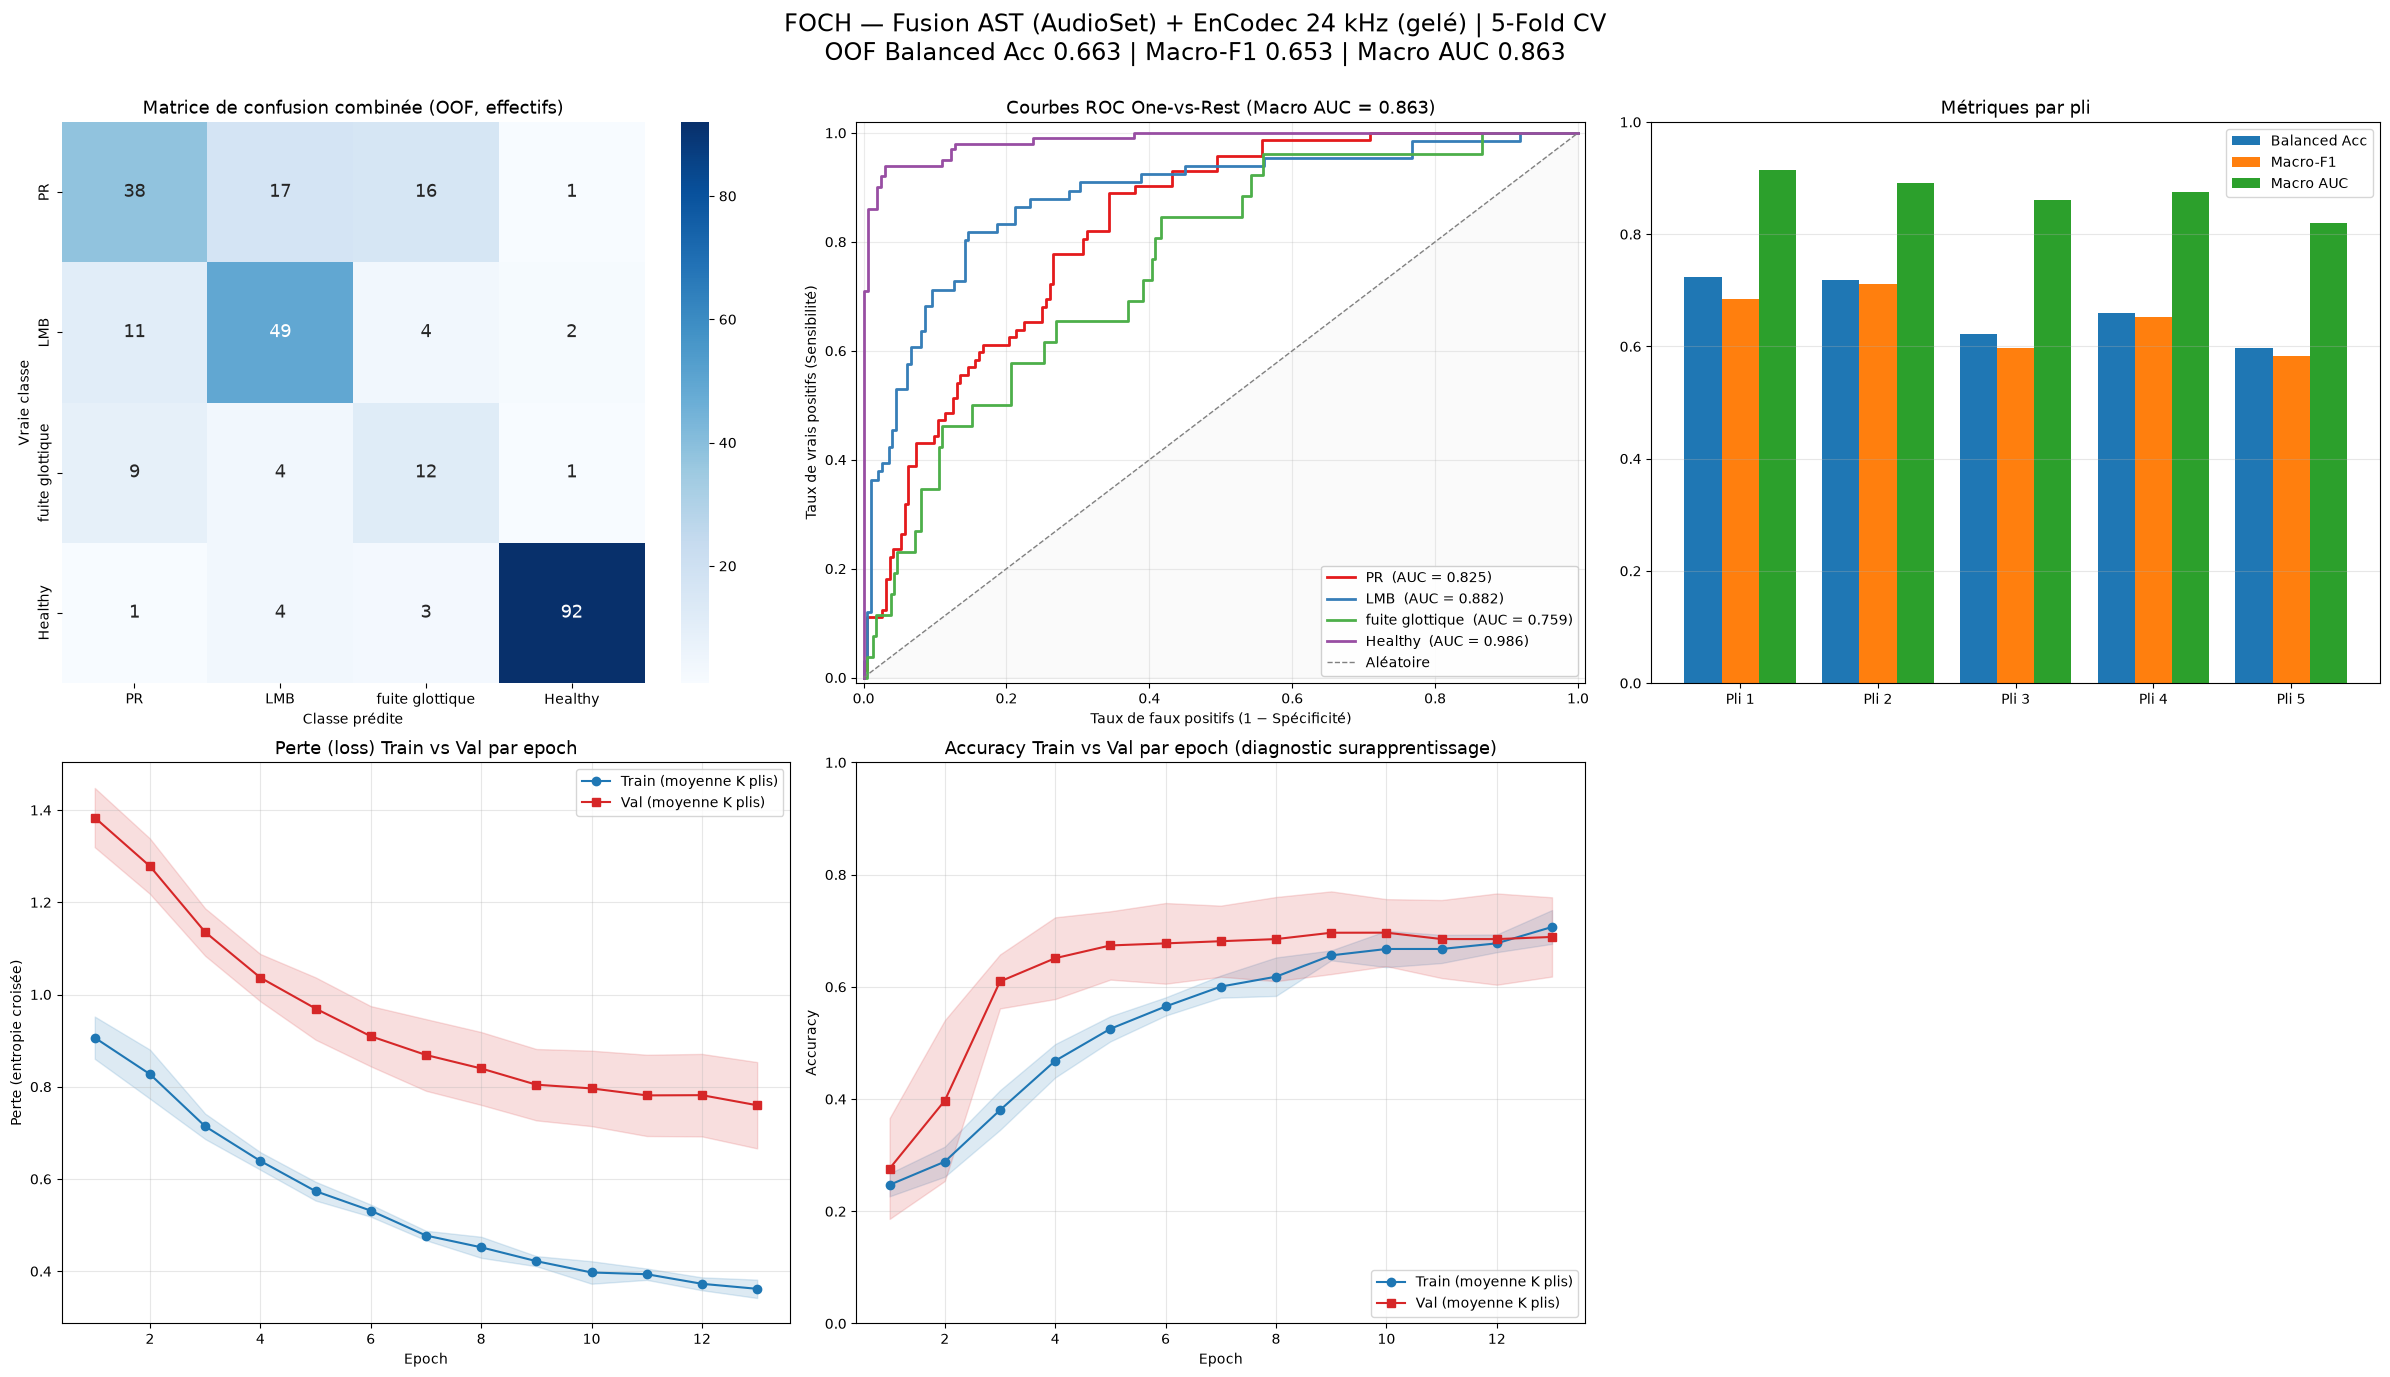


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • ast_codec_kfold_aug_dashboard.png
  • ast_codec_kfold_aug_metrics.json
  • ast_codec_kfold_aug_confusion.csv
  • ast_codec_kfold_aug_fold_metrics.csv


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold) + tableau de bord
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── Titre dynamique : reflète le preset BACKBONE réellement actif ─────────────
_arch_names = []
if WAVLM_VARIANT:               _arch_names.append(f'WavLM-{WAVLM_VARIANT.capitalize()}')
if AUDIO_BACKBONE == 'ast':     _arch_names.append('AST (AudioSet)')
elif AUDIO_BACKBONE == 'cnn14': _arch_names.append('CNN14 (SpeechBrain)')
if USE_CODEC:                   _arch_names.append('EnCodec 24 kHz (gelé)')
_arch_txt = ' + '.join(_arch_names) if _arch_names else BACKBONE

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Tableau de bord 2×3 (agrandi) ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(f'FOCH — Fusion {_arch_txt} | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=17)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 13})
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)', fontsize=13)
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01]); axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})', fontsize=13)
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [0, 2] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[0, 2].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[0, 2].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[0, 2].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[0, 2].set_title('Métriques par pli', fontsize=13)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(True, axis='y', alpha=0.3)

# ── [1, 0] Perte (loss) Train vs Val par epoch ────────────────────────────────
# Nécessite fold_train_loss / fold_curves (historisés Cellule 7).
assert 'fold_train_loss' in globals() and len(fold_train_loss), \
    "fold_train_loss manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep_loss = min(min(len(h) for h in fold_train_loss),
                   min(len(h) for h in fold_curves))
tr_loss = np.array([h[:min_ep_loss] for h in fold_train_loss])   # (K, min_ep)
va_loss = np.array([h[:min_ep_loss] for h in fold_curves])
ep_loss = np.arange(1, min_ep_loss + 1)
axes[1, 0].plot(ep_loss, tr_loss.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, tr_loss.mean(0) - tr_loss.std(0), tr_loss.mean(0) + tr_loss.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 0].plot(ep_loss, va_loss.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, va_loss.mean(0) - va_loss.std(0), va_loss.mean(0) + va_loss.std(0),
                        color='#d62728', alpha=0.15)
if UNFREEZE_ENABLED and UNFREEZE_AT_EPOCH < min_ep_loss:
    axes[1, 0].axvline(UNFREEZE_AT_EPOCH + 1, color='grey', ls='--', lw=1,
                       label=f'Dégel WavLM (epoch {UNFREEZE_AT_EPOCH + 1})')
axes[1, 0].set_title('Perte (loss) Train vs Val par epoch', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Perte (entropie croisée)')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# ── [1, 1] Diagnostic de surapprentissage : Train vs Val accuracy / epoch ─────
# Nécessite fold_train_acc / fold_val_acc (historisés Cellule 7).
assert 'fold_train_acc' in globals() and 'fold_val_acc' in globals() \
        and len(fold_train_acc) and len(fold_val_acc), \
    "fold_train_acc/fold_val_acc manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep = min(min(len(h) for h in fold_train_acc),
             min(len(h) for h in fold_val_acc))
tr = np.array([h[:min_ep] for h in fold_train_acc])   # (K, min_ep)
va = np.array([h[:min_ep] for h in fold_val_acc])
ep = np.arange(1, min_ep + 1)
axes[1, 1].plot(ep, tr.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 1].fill_between(ep, tr.mean(0) - tr.std(0), tr.mean(0) + tr.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 1].plot(ep, va.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 1].fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                        color='#d62728', alpha=0.15)
if UNFREEZE_ENABLED and UNFREEZE_AT_EPOCH < min_ep:
    axes[1, 1].axvline(UNFREEZE_AT_EPOCH + 1, color='grey', ls='--', lw=1,
                       label=f'Dégel WavLM (epoch {UNFREEZE_AT_EPOCH + 1})')
axes[1, 1].set_title('Accuracy Train vs Val par epoch (diagnostic surapprentissage)',
                     fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# ── [1, 2] (grille 2×3 pour accueillir CM/ROC/Métriques + Loss/Accuracy) ──────
axes[1, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           _arch_txt,
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')

In [10]:
print(type(fold_curves[0]))
print(fold_curves[0] if isinstance(fold_curves[0], dict) else fold_curves[0][:5])

<class 'list'>
[1.3466842004231043, 1.2035407764571053, 1.066327520779201, 0.9893091746738979, 0.8772394529410771]


## 9. Synthèse et prochaines étapes

Ce notebook met en œuvre un **classifieur multi-branche entièrement configurable** (préréglages `BACKBONE`, Cellule 1) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli. Le backbone n'est pas figé en dur : `cnn14`, `ast`, leurs variantes solo, et `wavlm_base`/`wavlm_large` partagent la même boucle d'entraînement (Cellule 7) et le même `Dataset` bi-entrée (Cellule 4) — seule la dimension de fusion s'adapte automatiquement selon les branches sélectionnées (`MultiBranchFusion`, Cellule 6).

**Configuration actuellement active : `BACKBONE = 'ast_large'`** → fusion **AST (AudioSet, 768-d, gelé)** ⊕ **WavLM-Large (1024-d, gelé)** → 1792-d.

**Choix méthodologiques clés :**
- **Architecture modulaire** : une branche « audio-domaine » spectrale au choix (CNN14 *ou* AST, toutes deux pré-entraînées sur AudioSet) + une branche WavLM optionnelle (Base/Large) — cf. `_BACKBONE_PRESETS`, Cellule 1.
- **AST (config active)** : Vision Transformer pré-entraîné sur AudioSet en spectrogramme fbank 1024×128, utilisé ici en extracteur d'embeddings gelé (`pooler_output` 768-d) — capture des motifs spectro-temporels globaux sans réentraînement sur les ~300 échantillons FOCH.
- **WavLM-Large gelé** : détail acoustique fin (jitter, shimmer, apériodicité) en complément de la vue AST, plus macroscopique.
- **Tête de fusion régularisée** : les deux branches étant gelées, seule la tête MLP (`Dropout → Linear → LayerNorm → Dropout → ReLU → Linear`) est entraînable — cf. Cellule 6, avec dropout d'entrée et dropout interne renforcés pour limiter le surapprentissage observé sur ce head par ailleurs surparamétré au regard de la taille du jeu.
- **Validation croisée K-Fold** : métriques OOF + moyenne ± écart-type par pli.
- **Augmentation sans fuite** : segments injectés uniquement dans le train, patients de validation exclus.

**Pistes probables d'amélioration ultérieures :**
1. Comparer les presets (`ast_large`, `ast` +WavLM-Base, `cnn14`, `wavlm_large` seul, etc.) — la sonde VRAM (Cellule 6b) et la boucle (Cellule 7) s'adaptent automatiquement à chacun.
2. **Dégel progressif** (*progressive unfreezing*) d'AST et/ou WavLM au-delà de l'epoch de stabilisation de la tête (`UNFREEZE_ENABLED`, Cellule 1).
3. **SpecAugment** sur l'entrée fbank d'AST.
4. **Ensembling** des K modèles de plis à l'inférence.
5. **Audit qualité** des doublons d'homonymes (`MARTIN`) via `patient_id`.
6. Réduire encore `fusion_dim` (projection/PCA avant la tête) si le head reste sujet au surapprentissage malgré le dropout renforcé.

**Branche codec neuronal (ajout).** Une branche **EnCodec 24 kHz** (`facebook/encodec_24khz`) a été ajoutée aux presets (`codec_solo`, `wavlm_codec`, `ast_codec`) afin de tester une hypothèse précise : WavLM comme AST sont biaisés vers le **contenu phonétique / sémantique** (pré-entraînement par prédiction masquée et par étiquetage AudioSet), alors qu'un codec est entraîné à **préserver le détail fin de reconstruction** — bruit apériodique, irrégularité cycle-à-cycle, structure de souffle. C'est exactement le type d'information qui distingue les classes pathologiques les plus difficiles à séparer ici (`fuite glottique` vs `LMB`). La branche exploite la sortie **continue** de l'encodeur, **avant** la quantification RVQ (le goulet de quantification est conçu pour la compression et détruirait ce détail), suivie d'une moyenne temporelle. Comme WavLM et AST, le codec reste **gelé et en pure inférence** : ~300 enregistrements FOCH ne permettent pas de réaffiner son encodeur sans détruire la représentation pré-entraînée. Note : son latent ne fait que **128-d**, il n'élargit donc pas significativement la tête de fusion (une projection reste disponible via `CODEC_BOTTLENECK_DIM`, désactivée par défaut).

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8). Selon le preset `BACKBONE` choisi en Cellule 1, la Cellule 6 charge AST depuis `AST_DIR` (local) et/ou WavLM depuis `WAVLM_DIRS`, et ne télécharge le checkpoint CNN14 (`speechbrain/cnn14-esc50`) que si ce backbone est sélectionné. La Cellule 7 entraîne **K = 5 modèles** : prévoir un GPU CUDA et un temps d'exécution conséquent.

## 9. Synthèse et prochaines étapes

Ce notebook met en œuvre un **classifieur multi-branche entièrement configurable** (préréglages `BACKBONE`, Cellule 1) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli. Le backbone n'est pas figé en dur : `cnn14`, `ast`, leurs variantes solo, et `wavlm_base`/`wavlm_large` partagent la même boucle d'entraînement (Cellule 7) et le même `Dataset` bi-entrée (Cellule 4) — seule la dimension de fusion s'adapte automatiquement selon les branches sélectionnées (`MultiBranchFusion`, Cellule 6).

**Configuration actuellement active : `BACKBONE = 'ast_large'`** → fusion **AST (AudioSet, 768-d, gelé)** ⊕ **WavLM-Large (1024-d, gelé)** → 1792-d.

**Choix méthodologiques clés :**
- **Architecture modulaire** : une branche « audio-domaine » spectrale au choix (CNN14 *ou* AST, toutes deux pré-entraînées sur AudioSet) + une branche WavLM optionnelle (Base/Large) — cf. `_BACKBONE_PRESETS`, Cellule 1.
- **AST (config active)** : Vision Transformer pré-entraîné sur AudioSet en spectrogramme fbank 1024×128, utilisé ici en extracteur d'embeddings gelé (`pooler_output` 768-d) — capture des motifs spectro-temporels globaux sans réentraînement sur les ~300 échantillons FOCH.
- **WavLM-Large gelé** : détail acoustique fin (jitter, shimmer, apériodicité) en complément de la vue AST, plus macroscopique.
- **Tête de fusion régularisée** : les deux branches étant gelées, seule la tête MLP (`Dropout → Linear → LayerNorm → Dropout → ReLU → Linear`) est entraînable — cf. Cellule 6, avec dropout d'entrée et dropout interne renforcés pour limiter le surapprentissage observé sur ce head par ailleurs surparamétré au regard de la taille du jeu.
- **Validation croisée K-Fold** : métriques OOF + moyenne ± écart-type par pli.
- **Augmentation sans fuite** : segments injectés uniquement dans le train, patients de validation exclus.

**Pistes probables d'amélioration ultérieures :**
1. Comparer les presets (`ast_large`, `ast` +WavLM-Base, `cnn14`, `wavlm_large` seul, etc.) — la sonde VRAM (Cellule 6b) et la boucle (Cellule 7) s'adaptent automatiquement à chacun.
2. **Dégel progressif** (*progressive unfreezing*) d'AST et/ou WavLM au-delà de l'epoch de stabilisation de la tête (`UNFREEZE_ENABLED`, Cellule 1).
3. **SpecAugment** sur l'entrée fbank d'AST.
4. **Ensembling** des K modèles de plis à l'inférence.
5. **Audit qualité** des doublons d'homonymes (`MARTIN`) via `patient_id`.
6. Réduire encore `fusion_dim` (projection/PCA avant la tête) si le head reste sujet au surapprentissage malgré le dropout renforcé.

**Branche codec neuronal (ajout).** Une branche **EnCodec 24 kHz** (`facebook/encodec_24khz`) a été ajoutée aux presets (`codec_solo`, `wavlm_codec`, `ast_codec`) afin de tester une hypothèse précise : WavLM comme AST sont biaisés vers le **contenu phonétique / sémantique** (pré-entraînement par prédiction masquée et par étiquetage AudioSet), alors qu'un codec est entraîné à **préserver le détail fin de reconstruction** — bruit apériodique, irrégularité cycle-à-cycle, structure de souffle. C'est exactement le type d'information qui distingue les classes pathologiques les plus difficiles à séparer ici (`fuite glottique` vs `LMB`). La branche exploite la sortie **continue** de l'encodeur, **avant** la quantification RVQ (le goulet de quantification est conçu pour la compression et détruirait ce détail), suivie d'une moyenne temporelle. Comme WavLM et AST, le codec reste **gelé et en pure inférence** : ~300 enregistrements FOCH ne permettent pas de réaffiner son encodeur sans détruire la représentation pré-entraînée. Note : son latent ne fait que **128-d**, il n'élargit donc pas significativement la tête de fusion (une projection reste disponible via `CODEC_BOTTLENECK_DIM`, désactivée par défaut).

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8). Selon le preset `BACKBONE` choisi en Cellule 1, la Cellule 6 charge AST depuis `AST_DIR` (local) et/ou WavLM depuis `WAVLM_DIRS`, et ne télécharge le checkpoint CNN14 (`speechbrain/cnn14-esc50`) que si ce backbone est sélectionné. La Cellule 7 entraîne **K = 5 modèles** : prévoir un GPU CUDA et un temps d'exécution conséquent.